# Bitcoin Price Forecasting with Heterogeneous Financial Indicators

## Problem Statement

**Research goal:** Predicting Bitcoin price using heterogeneous financial, macroeconomic, crypto-market and technical indicators, and comparing classical time-series, linear, tree-based, ensemble and neural forecasting methods.

The project is a supervised forecasting/data mining task. For each observation frequency, the feature vector available at time `t` is used to predict the Bitcoin price at `t+1`. This one-step-ahead framing avoids using same-period target information as if it were known before the forecast.

The target variable is `BTC`. The explanatory variables include crypto-market assets, equity/ETF proxies, commodities, FX rates, technical indicators, calendar variables, macroeconomic indicators, blockchain/market-sentiment variables, and lagged or rolling BTC features.


## Setup

The notebook uses frozen CSV datasets created by the existing data collection scripts. No external API call is required to reproduce the report.


In [1]:
import os
from pathlib import Path
import warnings
from collections import OrderedDict

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as pltЗ
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## Data Collection

The project uses three consolidated datasets from the existing BTC forecasting project:

- `new_day_df.csv`: daily observations.
- `new_hour_df.csv`: hourly observations.
- `new_5min_df.csv`: 5-minute observations.

The raw collection and merging logic is kept in `get_data.py`. The report uses the frozen CSV files so that all experiments are reproducible without network access. Every dataset used here has well above 50 objects and 7-10 features.


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'new_day_df.csv').exists():
    PROJECT_DIR = Path(__file__).parent if '__file__' in dir() else PROJECT_DIR

DATA_CONFIG = OrderedDict({
    'daily': {
        'file': 'new_day_df.csv',
        'date_col': 'Date',
        'test_size': 216,
        'horizon': 1,
        'ma_window': 7,
        'seasonal_period': 7,
        'max_features': 30,
    },
    'hourly': {
        'file': 'new_hour_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 24,
        'seasonal_period': 24,
        'max_features': 25,
    },
    '5min': {
        'file': 'new_5min_df.csv',
        'date_col': 'Datetime',
        'test_size': 0.20,
        'horizon': 1,
        'ma_window': 12,
        'seasonal_period': 288,
        'max_features': 20,
    },
})

def load_dataset(file_name, date_col):
    df = pd.read_csv(PROJECT_DIR / file_name, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

datasets = {
    frequency: load_dataset(cfg['file'], cfg['date_col'])
    for frequency, cfg in DATA_CONFIG.items()
}

for frequency, df in datasets.items():
    print(f'{frequency}: {df.shape[0]} rows, {df.shape[1]} columns, {df.index.min()} -> {df.index.max()}')


daily: 2912 rows, 88 columns, 2018-06-20 00:00:00 -> 2026-06-09 00:00:00
hourly: 20922 rows, 68 columns, 2024-06-11 12:00:00 -> 2026-06-09 23:00:00
5min: 16589 rows, 68 columns, 2026-04-13 09:35:00 -> 2026-06-09 23:55:00


## Dataset Summary with Basic Statistics and Plots

This section checks dataset size, observation periods, feature groups, missing values, basic target statistics, and target distribution.


In [3]:
CRYPTO_COLS = {
    'BTC', 'ETH', 'Bitcoin_Cash', 'Cardano', 'Dogecoin', 'Ethereum_Classic',
    'Chainlink', 'Litecoin', 'TRON', 'Tether', 'Stellar', 'XRP', 'BTC_Supply',
    'Feer_Greed_value'
}
MACRO_COLS = {
    'Unemployment_Rate', 'Non_Farm_Payrolls', 'Initial_Jobless_Claims', 'CPI',
    'PCE_Price_Index', 'Consumer_Confidence_Index', 'Retail_Sales', 'Housing_Starts',
    'Building_Permits', 'M2_Money_Supply', 'Real_Interest_Rate', 'Fed_Funds_Rate',
    'Reverse_Repo_Volume', 'Debt', 'Real_GDP'
}
TECHNICAL_TOKENS = (
    'RSI', 'MACD', 'ATR', 'OBV', 'SMA', 'EMA', 'TEMA', 'KAMA', 'HMA', 'ALMA',
    'T3', 'SSF', 'VIDYA', 'ZL_EMA', 'BTC_lag', 'BTC_mean', 'BTC_std',
    'Open', 'High', 'Low', 'Close', 'Volume', 'Taker buy'
)
CALENDAR_COLS = {'day', 'month', 'quarter', 'year', 'day_of_week', 'hour', 'minute', 'is_holiday'}
FX_TOKENS = ('USD/', 'EUR/', 'GBP/', 'AUD/')
COMMODITY_COLS = {'Gold', 'Silver', 'Copper', 'Platinum', 'Brent_Oil', 'WTI', 'Brent', 'Natural_Gas'}

def feature_group(col):
    if col in CALENDAR_COLS:
        return 'calendar'
    if col in MACRO_COLS:
        return 'macroeconomic'
    if col in CRYPTO_COLS:
        return 'crypto-market'
    if col in COMMODITY_COLS:
        return 'commodities'
    if any(token in col for token in TECHNICAL_TOKENS):
        return 'technical/lagged BTC'
    if any(token in col for token in FX_TOKENS):
        return 'FX'
    return 'equity/ETF/market index'

summary_rows = []
group_rows = []
for frequency, df in datasets.items():
    target = df['BTC']
    missing_by_col = df.isna().sum()
    summary_rows.append({
        'frequency': frequency,
        'objects': len(df),
        'features_excluding_target': df.shape[1] - 1,
        'start': df.index.min(),
        'end': df.index.max(),
        'missing_values_total': int(missing_by_col.sum()),
        'columns_with_missing': int((missing_by_col > 0).sum()),
        'BTC_mean': target.mean(),
        'BTC_std': target.std(),
        'BTC_min': target.min(),
        'BTC_median': target.median(),
        'BTC_max': target.max(),
    })
    feature_groups = pd.Series([feature_group(col) for col in df.columns if col != 'BTC']).value_counts()
    for group, count in feature_groups.items():
        group_rows.append({'frequency': frequency, 'feature_group': group, 'count': int(count)})

summary_df = pd.DataFrame(summary_rows)
feature_group_df = pd.DataFrame(group_rows).sort_values(['frequency', 'feature_group'])

display(summary_df)
display(feature_group_df.pivot_table(index='feature_group', columns='frequency', values='count', fill_value=0).astype(int))


,frequency,objects,features_excluding_target,start,end,missing_values_total,columns_with_missing,BTC_mean,BTC_std,BTC_min,BTC_median,BTC_max
0,daily,2912,87,2018-06-20 00:00:00,2026-06-09 00:00:00,0,0,40986.414848,32640.358450,3235.051208,31075.478516,124724.794922
1,hourly,20922,67,2024-06-11 12:00:00,2026-06-09 23:00:00,0,0,87500.946850,18841.613509,50197.403320,88479.541016,125897.021484
2,5min,16589,67,2026-04-13 09:35:00,2026-06-09 23:55:00,0,0,75389.482533,5332.657816,59203.291992,76850.546875,82722.105469


frequency,5min,daily,hourly
feature_group,,,
FX,6,6,6
calendar,2,5,2
crypto-market,11,13,11
equity/ETF/market index,38,38,38
macroeconomic,0,15,0
technical/lagged BTC,10,10,10


In [4]:
basic_stats = pd.concat(
    {frequency: df['BTC'].describe() for frequency, df in datasets.items()},
    axis=1
).T
basic_stats['skew'] = [datasets[f]['BTC'].skew() for f in basic_stats.index]
basic_stats['kurtosis'] = [datasets[f]['BTC'].kurtosis() for f in basic_stats.index]
display(basic_stats.round(2))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
daily,2912.0,40986.41,32640.36,3235.05,10365.88,31075.48,63451.00,124724.79,0.75,-0.54
hourly,20922.0,87500.95,18841.61,50197.40,68795.79,88479.54,103877.84,125897.02,0.02,-1.22
5min,16589.0,75389.48,5332.66,59203.29,74247.62,76850.55,78398.89,82722.11,-1.48,1.39


In [5]:
import matplotlib.pyplot as plt

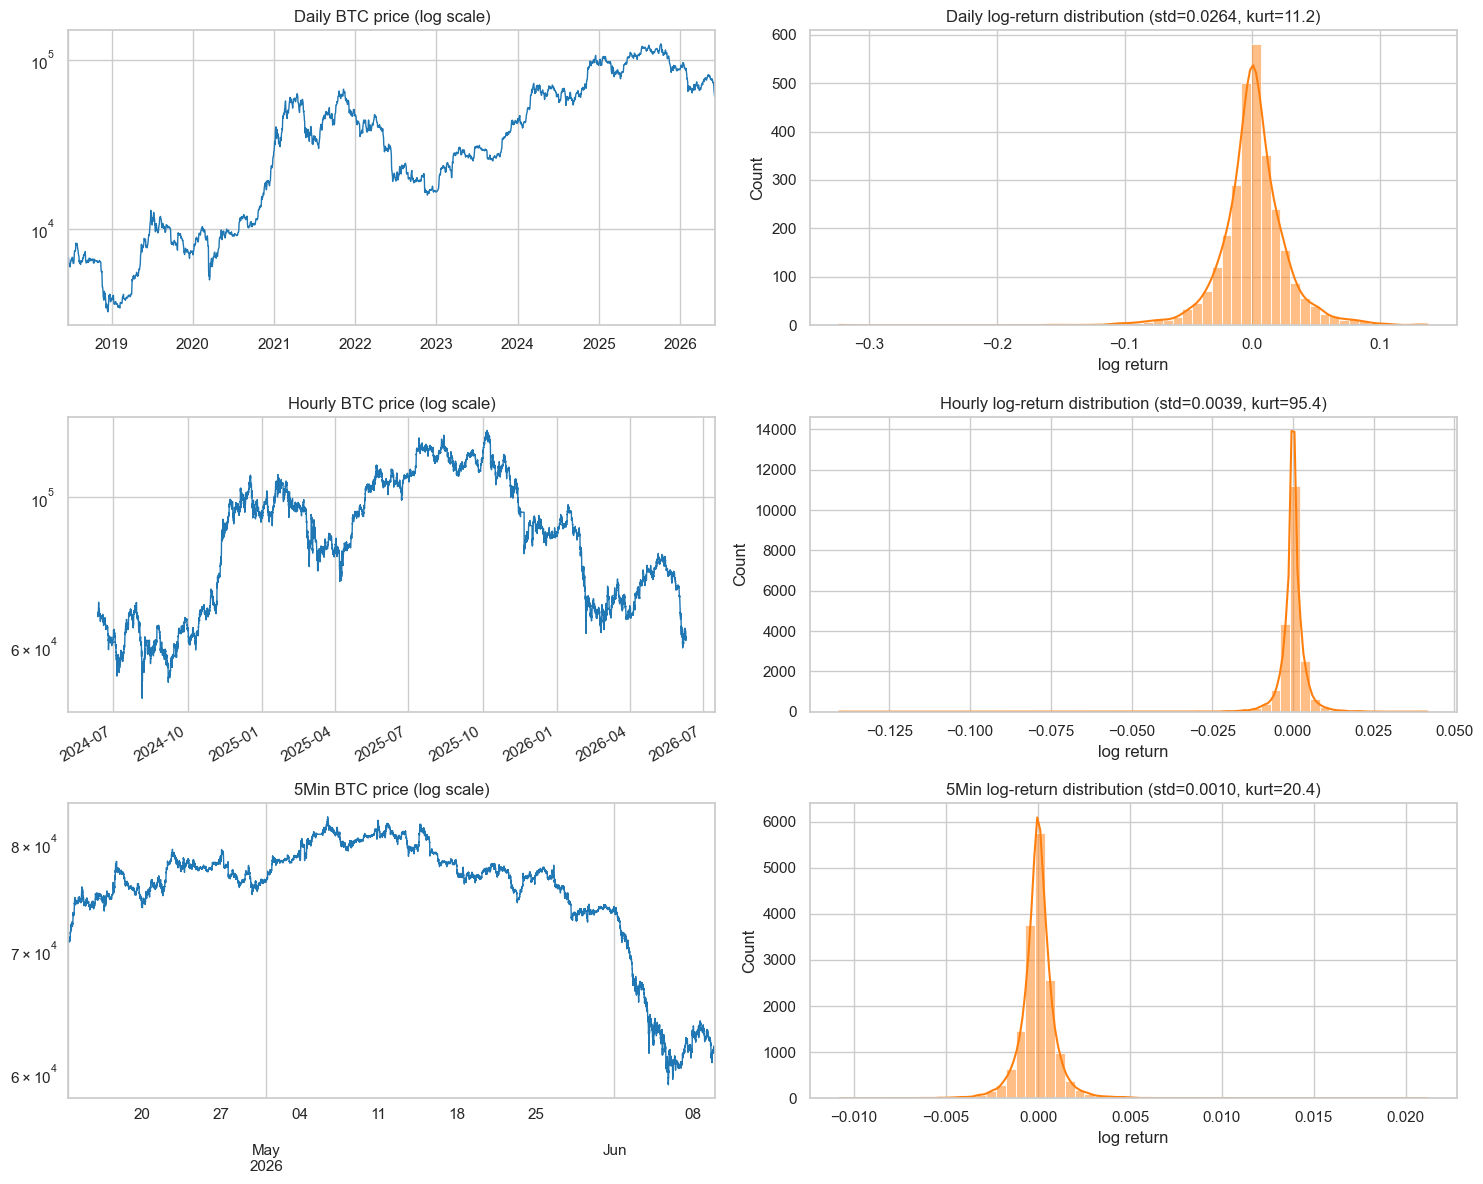

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, (frequency, df) in enumerate(datasets.items()):
    # Левая колонка: уровень цены в лог-шкале — виден мультипликативный тренд/режимы.
    df['BTC'].plot(ax=axes[row, 0], color='tab:blue', linewidth=1.0, logy=True)
    axes[row, 0].set_title(f'{frequency.title()} BTC price (log scale)')
    axes[row, 0].set_xlabel('')
    # Правая колонка: распределение лог-доходностей — целевая переменная моделей.
    # В отличие от уровня цены, доходности (около)стационарны и центрированы у нуля,
    # поэтому их распределение информативно (тяжёлые хвосты, эксцесс); гистограмма
    # самого уровня была бы лишь мультимодальным отражением ценовых режимов.
    logret = np.log(df['BTC']).diff().dropna()
    sns.histplot(logret, bins=60, kde=True, ax=axes[row, 1], color='tab:orange')
    axes[row, 1].set_title(f'{frequency.title()} log-return distribution '
                           f'(std={logret.std():.4f}, kurt={logret.kurt():.1f})')
    axes[row, 1].set_xlabel('log return')
plt.tight_layout()
plt.show()


### Missing Values and Outliers

The consolidated files have no missing values. The modeling pipeline still includes median imputation to make the workflow robust to future data refreshes. Outliers are handled inside the training pipeline by clipping numeric features to train-fitted 1st and 99th percentiles before robust scaling.


In [7]:
def iqr_outlier_count(frame):
    numeric = frame.select_dtypes(include=[np.number])
    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = numeric.lt(lower, axis=1) | numeric.gt(upper, axis=1)
    return mask.sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    frequency: df.isna().sum() for frequency, df in datasets.items()
}).fillna(0).astype(int)

display(missing_table.sum().rename('missing_values_by_frequency').to_frame())

outlier_rows = []
for frequency, df in datasets.items():
    counts = iqr_outlier_count(df).head(10)
    for feature, count in counts.items():
        outlier_rows.append({'frequency': frequency, 'feature': feature, 'IQR_outlier_count': int(count)})

display(pd.DataFrame(outlier_rows))


,missing_values_by_frequency
daily,0
hourly,0
5min,0


,frequency,feature,IQR_outlier_count
0,daily,Tether,604
1,daily,Initial_Jobless_Claims,581
2,daily,Unemployment_Rate,456
3,daily,XRP,411
4,daily,Platinum_Future,365
5,daily,Gold_Future,344
6,daily,MACD,323
7,daily,MicroStrategy,282
8,daily,TRON,272
9,daily,Natural_Gas_Future,271


## Methodology

The complete pipeline is:

1. Load frozen datasets (Daily, Hourly, 5-minute) and validate size, period, missing values, and feature groups.
2. Convert the task to one-step-ahead forecasting: features at `t` predict `BTC` at `t+1`.
3. Use time-based train/test splits only. No shuffling is used.
4. Use a fixed shortlist of the strongest train-period predictors per frequency (`TOP_FEATURES`), pre-computed once from train-only absolute correlations with the next-period target.
5. Fit preprocessing only on training data: median imputation, 1/99 percentile clipping, robust scaling.
6. Train two baselines (Naive last value, Moving average), four Gradient Boosting variants (HistGradientBoosting, LightGBM, XGBoost, CatBoost), and four neural sequence architectures (LSTM, GRU, Stacked LSTM, CNN-LSTM, all built with `CryptoNet`).
7. Compare models by MAE, RMSE, SMAPE, MASE, and train/test gap; select the best Gradient Boosting model per frequency (`best_gb`).
8. Interpret `best_gb` with permutation importance and SHAP, and the NN models with gradient-based feature attribution.
9. Analyze residuals and compare model behavior during normal periods versus sharp BTC growth/drop periods.

This setup directly targets the thesis comparison: **Gradient Boosting ensembles vs. Neural Networks**, evaluated at Daily, Hourly, and 5-minute granularities, with feature importance and shock-period error analysis as the basis for interpretation.


In [8]:
import sys
sys.path.append(str(PROJECT_DIR))

from ml_models import (
    CryptoNetRegressor, _sample_crypto_hparams, run_optuna_study,
    set_global_seed, DEVICE,
)
set_global_seed(RANDOM_STATE)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(np.abs(y_true - y_pred), denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return float(np.mean(ratio))


def mase(y_true, y_pred, y_train):
    y_train = np.asarray(y_train, dtype=float)
    scale = np.mean(np.abs(np.diff(y_train)))
    if scale == 0 or np.isnan(scale):
        return np.nan
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)


def regression_metrics(y_true, y_pred, y_train):
    frame = pd.concat([
        pd.Series(y_true, name='true'),
        pd.Series(y_pred, name='pred')
    ], axis=1).dropna()
    if frame.empty:
        return {'MAE': np.nan, 'RMSE': np.nan, 'MASE': np.nan, 'DA': np.nan}
    return {
        'MAE': mean_absolute_error(frame['true'], frame['pred']),
        'RMSE': np.sqrt(mean_squared_error(frame['true'], frame['pred'])),
        'MASE': mase(frame['true'], frame['pred'], y_train),
        # Directional Accuracy: доля совпадений знака (для таргета-доходности)
        'DA': float(np.mean((frame['true'].values > 0) == (frame['pred'].values > 0))),
    }


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


def make_preprocessed_model(model, scale=True):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', RobustScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


SMAPE_SCORER = make_scorer(smape, greater_is_better=False)


In [9]:
# Hardcoded configuration: feature shortlists and model hyperparameters.
#
# TOP_FEATURES — пул признаков-кандидатов для пофолдового top-k отбора (НЕ
# фиксированный шорт-лист). Пять прежних признаков уровня цены (BTC_lag*, BTC_mean5)
# заменены на признаки ДОХОДНОСТИ (ret_lag*, ret_mean5, ret_std10): таргет теперь —
# лог-доходность, и предикторы тоже должны быть стационарными (импульс/волатильность),
# иначе модель ключевается на нестационарном уровне цены. Все ret_*-признаки строго
# лагированы в prep_returns. Остальной пул — экзогенные ряды (уже лагированы в
# get_data) и RSI.
TOP_FEATURES = {
    'daily': [
        'ret_lag1', 'ret_mean5', 'ret_lag2', 'ret_lag5', 'ret_lag10', 'ret_std10',
        'SPDR_Communications', 'TRON', 'SPDR_Financials', 'S&P_500', 'Invesco_QQQ',
        'NASDAQ_100', 'SPDR_Industrials', 'Meta', 'VanEck_Semiconductor_ETF', 'MicroStrategy',
        'SPDR_Consumer_Discretionary', 'Dow_Jones', 'SPDR_Tech', 'Google', 'NVIDIA',
        'Gold_Future', 'Microsoft', 'iShares_Semiconductor_ETF', 'Amazon', 'Silver_Future',
        'XRP', 'ATR', 'Apple', 'ETH', 'year',
    ],
    'hourly': [
        'ret_lag1', 'ret_mean5', 'ret_lag2', 'ret_lag5', 'ret_lag10', 'ret_std10',
        'OBV', 'XRP', 'TRON', 'Stellar', 'ARK_NextGen_Internet_ETF',
        'Meta', 'SPDR_Financials', 'MicroStrategy', 'Litecoin', 'SPDR_Communications',
        'ARKK_ETF', 'SPDR_Consumer_Discretionary', 'Adobe', 'Amazon', 'Cardano',
        'SPDR_Industrials', 'Chainlink', 'Tesla', 'Bitcoin_Cash', 'SPDR_HealthCare',
    ],
    '5min': [
        'ret_lag1', 'ret_mean5', 'ret_lag2', 'ret_lag5', 'ret_lag10', 'ret_std10',
        'MicroStrategy', 'Cardano', 'Dogecoin', 'Chainlink', 'Ethereum_Classic',
        'Litecoin', 'AUD/USD', 'USD/JPY', 'Amazon', 'XRP',
        'SPDR_HealthCare', 'Google', 'USD/CAD', 'OBV', 'Brent_Oil_Future',
    ],
}

# Gradient boosting hyperparameters (structural params fixed; lr/n_est tuned per fold by Optuna).
GB_HYPERPARAMS = {
    'HistGradientBoosting': dict(
        max_iter=260, learning_rate=0.05, l2_regularization=0.05, random_state=RANDOM_STATE,
    ),
    'LightGBM': dict(
        n_estimators=320, learning_rate=0.03, num_leaves=31, min_child_samples=20,
        subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': dict(
        objective='reg:squarederror', n_estimators=320, learning_rate=0.03, max_depth=3,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'CatBoost': dict(
        iterations=320, learning_rate=0.03, depth=6, l2_leaf_reg=3.0,
        random_state=RANDOM_STATE, verbose=False,
    ),
}

# Sequence-model (CryptoNet) per-frequency settings.
NN_CONFIG = {
    'daily':  {'window_size': 10, 'epochs': 20, 'batch_size': 16},
    'hourly': {'window_size': 24, 'epochs': 15, 'batch_size': 32},
    '5min':   {'window_size': 24, 'epochs': 15, 'batch_size': 64},
}
NN_ARCHITECTURES = ['LSTM', 'GRU', 'StackedLSTM', 'CNN_LSTM']
NN_OPTUNA_TRIALS = 5  # retained for reference; the experiment runs through walk-forward

# Walk-forward split configuration per frequency.
# Daily  : expanding window (5 folds, first 50% of rows = initial train).
# Hourly : rolling window, ~125 days train / ~25 days test per fold.
# 5-min  : rolling window, ~8 days train  / ~2 days test per fold.
# Optuna retunes every model on every fold with WF_OPTUNA_TRIALS trials.
SPLIT_CONFIG = {
    'daily':  {'type': 'expanding', 'n_splits': 5, 'min_train_frac': 0.5},
    'hourly': {'type': 'rolling',   'n_splits': 5, 'train_size': 3000, 'test_size': 600},
    '5min':   {'type': 'rolling',   'n_splits': 5, 'train_size': 2400, 'test_size': 600},
}
WF_OPTUNA_TRIALS = 5
WF_TOP_K = 15   # features retained per fold via |Pearson| ranking on train fold only

# Annualisation constant for Sharpe ratio in backtest_summary
PERIODS_PER_YEAR = {'daily': 252, 'hourly': 8760, '5min': 105120}


In [10]:
# Подготовка датасетов под прогноз ДОХОДНОСТИ (а не уровня цены).
#
# Мотивация: уровень цены BTC нестационарен и трендовый. (1) Бустинги не
# экстраполируют за пределы диапазона таргета на трейне -> на растущем ряду они
# систематически недооценивают в поздних фолдах, что делает сравнение GB vs NN
# некорректным; (2) на уровне SMAPE вырождается до персистентности, а MASE
# завышается из-за смены ценового режима между трейном и тестом. Переход к
# лог-доходности r_t = log(P_t) - log(P_{t-1}) делает таргет (почти) стационарным:
# деревьям не нужно экстраполировать, метрики (включая Directional Accuracy) обретают
# смысл, а цена восстанавливается как P_t = P_{t-1} * exp(r_t).

RET_LAGS = [1, 2, 5, 10]
# Контемпоранные BTC-производные из CSV посчитаны по "текущему" бару t и содержат
# BTC_t -> при прогнозе r_t это утечка. Сдвигаем их на 1 бар. Экзогенные ряды уже
# лагированы в get_data, календарные признаки известны заранее -> их НЕ трогаем.
CONTEMP_BTC_COLS = ['RSI', 'MACD', 'ATR', 'OBV', 'BTC_mean5', 'BTC_std10']


def prep_returns(df, feature_cols):
    """Фрейм для walk-forward с таргетом-лог-доходностью.

    Возвращает копию df, в которой:
      * BTC        - исходный уровень цены (для восстановления цены и графиков);
      * BTC_logret - целевая переменная r_t = log(P_t) - log(P_{t-1});
      * ret_lag*, ret_mean5, ret_std10 - строго лагированные (>= t-1) признаки
        доходности (импульс/волатильность), не содержащие r_t;
      * контемпоранные BTC-производные (RSI/MACD/ATR/OBV/BTC_mean5/BTC_std10)
        сдвинуты на 1 бар, чтобы исключить BTC_t.
    Признаки строятся уже с нужным лагом, поэтому в самом walk-forward
    дополнительный shift НЕ применяется (единый источник истины о зазоре).
    """
    out = df.copy()
    price = out['BTC'].astype(float)
    ret = np.log(price).replace([np.inf, -np.inf], np.nan).diff()
    out['BTC_logret'] = ret
    for L in RET_LAGS:
        out[f'ret_lag{L}'] = ret.shift(L)
    out['ret_mean5'] = ret.shift(1).rolling(5).mean()
    out['ret_std10'] = ret.shift(1).rolling(10).std()
    present = [c for c in CONTEMP_BTC_COLS if c in out.columns]
    out[present] = out[present].shift(1)
    needed = list(dict.fromkeys(list(feature_cols) + ['BTC', 'BTC_logret']))
    return out.dropna(subset=needed)


wf_frames = OrderedDict(
    (freq, prep_returns(datasets[freq], TOP_FEATURES[freq])) for freq in DATA_CONFIG
)

# Сводка по подготовленным фреймам и пулу признаков-кандидатов.
split_summary = pd.DataFrame([
    {
        'frequency': freq,
        'rows': len(frame),
        'start': frame.index.min(),
        'end': frame.index.max(),
        'logret_mean': frame['BTC_logret'].mean(),
        'logret_std': frame['BTC_logret'].std(),
        'candidate_features': len(TOP_FEATURES[freq]),
    }
    for freq, frame in wf_frames.items()
])

feature_table = pd.DataFrame([
    {'frequency': freq, 'rank': rank, 'feature': feat}
    for freq in wf_frames
    for rank, feat in enumerate(TOP_FEATURES[freq], start=1)
])

display(split_summary)
display(feature_table)


,frequency,rows,start,end,logret_mean,logret_std,candidate_features
0,daily,2901,2018-07-01 00:00:00,2026-06-09 00:00:00,0.000784,0.026410,31
1,hourly,20911,2024-06-11 19:00:00,2026-06-09 23:00:00,-0.000004,0.003861,26
2,5min,16578,2026-04-13 10:30:00,2026-06-09 23:55:00,-0.000008,0.001021,21


,frequency,rank,feature
0,daily,1,ret_lag1
1,daily,2,ret_mean5
2,daily,3,ret_lag2
3,daily,4,ret_lag5
4,daily,5,ret_lag10
...,...,...,...
73,5min,17,SPDR_HealthCare
74,5min,18,Google
75,5min,19,USD/CAD
76,5min,20,OBV


## Experiment Setup and Results

All models are evaluated on the same time-based splits per frequency. Gradient Boosting and baseline models use a fixed train-only feature shortlist (`TOP_FEATURES`) and hardcoded hyperparameters (`GB_HYPERPARAMS`). Each of the four NN architectures (LSTM, GRU, Stacked LSTM, CNN-LSTM) uses a windowed sequence representation (`NN_CONFIG`), with hyperparameters chosen per architecture/frequency by a small Optuna search (`NN_OPTUNA_TRIALS` trials), and train-only `RobustScaler` fits for both the BTC sequence and the exogenous features. Baselines do not use future observations. All scalers, imputers, and clipping bounds are fit on training data only.


In [11]:
def build_model_specs():
    """Gradient boosting candidates only, with hardcoded hyperparameters."""
    specs = OrderedDict()

    specs['HistGradientBoosting'] = make_preprocessed_model(
        HistGradientBoostingRegressor(**GB_HYPERPARAMS['HistGradientBoosting']),
        scale=False,
    )

    if HAS_LIGHTGBM:
        specs['LightGBM'] = make_preprocessed_model(
            LGBMRegressor(**GB_HYPERPARAMS['LightGBM']),
            scale=False,
        )

    if HAS_XGBOOST:
        specs['XGBoost'] = make_preprocessed_model(
            XGBRegressor(**GB_HYPERPARAMS['XGBoost']),
            scale=False,
        )

    if HAS_CATBOOST:
        specs['CatBoost'] = make_preprocessed_model(
            CatBoostRegressor(**GB_HYPERPARAMS['CatBoost']),
            scale=False,
        )

    return specs


In [12]:
import time as _time
from sklearn.base import clone

from walk_forward import (
    expanding_window_splits, rolling_window_splits, run_walk_forward,
)
from backtest import simulate_strategy, buy_and_hold, backtest_summary
from ml_models import compute_metrics

TARGET = 'BTC_logret'


def _family(name):
    if any(a in name for a in ('LSTM', 'GRU', 'CNN_LSTM', 'StackedLSTM')):
        return 'NN'
    if name in ('Naive (zero return)', 'Last return', 'Moving average'):
        return 'baseline'
    return 'GB'


def _get_splits(frequency, cfg, n):
    if cfg['type'] == 'expanding':
        return expanding_window_splits(n, cfg['n_splits'], cfg['min_train_frac'])
    return rolling_window_splits(n, cfg['train_size'], cfg['test_size'], n_splits=cfg['n_splits'])


def make_gb_factory(model_template):
    """Zero-arg callable producing a fresh clone of model_template."""
    def factory():
        return clone(model_template)
    return factory


def reconstruct_price_oof(oof_ret_df, price):
    """Восстановление цены из прогноза доходности: P_hat_t = P_{t-1} * exp(r_hat_t).

    oof_ret_df - OOF в пространстве доходностей (actual/predicted = лог-доходности).
    price      - полный ряд уровня цены BTC (datasets[freq]['BTC']).
    Возвращает OOF в пространстве цены для экономического бэктеста.
    """
    prev_price = price.shift(1)
    rows = []
    for model_name, grp in oof_ret_df.groupby('model'):
        grp = grp.sort_values('timestamp')
        p_prev = prev_price.reindex(grp['timestamp']).to_numpy(dtype=float)
        p_actual = price.reindex(grp['timestamp']).to_numpy(dtype=float)
        p_pred = p_prev * np.exp(grp['predicted'].to_numpy(dtype=float))
        rows.append(pd.DataFrame({
            'timestamp': grp['timestamp'].values,
            'actual': p_actual,
            'predicted': p_pred,
            'fold': grp['fold'].values,
            'model': model_name,
        }))
    return pd.concat(rows, ignore_index=True)


wf_metrics_all = {}      # freq -> per-fold metrics (return space)
wf_oof_all = {}          # freq -> OOF predictions (return space)
wf_oof_price_all = {}    # freq -> OOF reconstructed to price (for the backtest)

t_wf_start = _time.time()

for frequency, df_freq in wf_frames.items():
    print(f'\n=== Walk-forward: {frequency} (target = log-return) ===')

    n = len(df_freq)
    cfg = SPLIT_CONFIG[frequency]
    splits = _get_splits(frequency, cfg, n)
    nn_cfg = NN_CONFIG[frequency]
    feat_pool = TOP_FEATURES[frequency]

    freq_metrics_list = []
    freq_oof_list = []

    # 1. Gradient Boosting models
    for gb_name, gb_model_tpl in build_model_specs().items():
        print(f'  GB {gb_name}...', end=' ', flush=True)
        t0 = _time.time()
        mdf, odf = run_walk_forward(
            model_family='GB', model_name=gb_name,
            df=df_freq, target_col=TARGET, all_feature_cols=feat_pool,
            splits=splits, top_k=min(WF_TOP_K, len(feat_pool)),
            optuna_n_trials=WF_OPTUNA_TRIALS,
            gb_model_factory=make_gb_factory(gb_model_tpl),
            seed=RANDOM_STATE,
        )
        print(f'{_time.time()-t0:.0f}s  DA={mdf["DA"].mean():.3f}  MASE={mdf["MASE"].mean():.3f}')
        freq_metrics_list.append(mdf)
        freq_oof_list.append(odf)

    # 2. NN architectures
    for arch in NN_ARCHITECTURES:
        model_name = f'{arch} (sequence NN)'
        print(f'  NN {arch}...', end=' ', flush=True)
        t0 = _time.time()
        mdf, odf = run_walk_forward(
            model_family='NN', model_name=model_name,
            df=df_freq, target_col=TARGET, all_feature_cols=feat_pool,
            splits=splits, top_k=min(WF_TOP_K, len(feat_pool)),
            optuna_n_trials=WF_OPTUNA_TRIALS,
            nn_config=nn_cfg,
            seed=RANDOM_STATE,
        )
        print(f'{_time.time()-t0:.0f}s  DA={mdf["DA"].mean():.3f}  MASE={mdf["MASE"].mean():.3f}')
        freq_metrics_list.append(mdf)
        freq_oof_list.append(odf)

    # 3. Baselines in return space:
    #    Naive (zero return) -> r_hat = 0   (бенчмарк "случайное блуждание цены")
    #    Last return         -> r_hat_t = r_{t-1}   (персистентность доходности)
    #    Moving average      -> скользящее среднее прошлых доходностей
    ret = df_freq[TARGET]
    ma_window = DATA_CONFIG[frequency]['ma_window']
    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        actual = ret.iloc[test_idx]
        preds = {
            'Naive (zero return)': pd.Series(0.0, index=actual.index),
            'Last return': ret.shift(1).iloc[test_idx],
            'Moving average': ret.shift(1).rolling(ma_window, min_periods=1).mean().iloc[test_idx],
        }
        y_tr = ret.iloc[train_idx].to_numpy(dtype=float)
        for bname, bpred in preds.items():
            m = compute_metrics(actual.to_numpy(dtype=float), bpred.to_numpy(dtype=float), y_tr)
            freq_metrics_list.append(pd.DataFrame([{
                'fold': fold_idx, 'model': bname,
                'MAE': m['mae'], 'RMSE': m['rmse'], 'SMAPE': m['smape'],
                'MASE': m['mase'], 'DA': m['da'],
                'n_train': len(train_idx), 'n_test': len(test_idx),
            }]))
            freq_oof_list.append(pd.DataFrame({
                'timestamp': actual.index, 'actual': actual.to_numpy(dtype=float),
                'predicted': bpred.to_numpy(dtype=float), 'fold': fold_idx, 'model': bname,
            }))

    wf_metrics_all[frequency] = pd.concat(freq_metrics_list, ignore_index=True)
    wf_oof_all[frequency] = pd.concat(freq_oof_list, ignore_index=True)
    wf_oof_price_all[frequency] = reconstruct_price_oof(
        wf_oof_all[frequency], datasets[frequency]['BTC']
    )

print(f'\nTotal walk-forward time: {_time.time()-t_wf_start:.0f}s')

# Aggregate (mean across folds). Selection metric = Directional Accuracy (tie-break MASE).
agg_frames = []
for freq, mdf in wf_metrics_all.items():
    agg = mdf.groupby('model')[['MAE', 'RMSE', 'MASE', 'DA']].mean().reset_index()
    agg['frequency'] = freq
    agg['family'] = agg['model'].apply(_family)
    agg_frames.append(agg)
wf_agg = pd.concat(agg_frames, ignore_index=True)

_gb_names = set(build_model_specs().keys())
_nn_names = {f'{a} (sequence NN)' for a in NN_ARCHITECTURES}


def _best_by_da(names):
    sub_df = wf_agg[wf_agg['model'].isin(names)].copy()
    sub_df = sub_df.sort_values(['frequency', 'DA', 'MASE'], ascending=[True, False, True])
    return sub_df.groupby('frequency', as_index=False).head(1).reset_index(drop=True)


best_gb = _best_by_da(_gb_names)
best_nn = _best_by_da(_nn_names)

# Price-space continuity metrics (SMAPE/MAE on reconstructed price) for comparability
# with the prior level-target report. SMAPE is well-defined here (prices > 0).
price_metric_rows = []
for freq, pdf in wf_oof_price_all.items():
    for model_name, grp in pdf.groupby('model'):
        g = grp.dropna(subset=['actual', 'predicted'])
        if g.empty:
            continue
        price_metric_rows.append({
            'frequency': freq, 'model': model_name, 'family': _family(model_name),
            'SMAPE_price': 100 * smape(g['actual'].values, g['predicted'].values),
            'MAE_price': mean_absolute_error(g['actual'], g['predicted']),
        })
price_metrics = pd.DataFrame(price_metric_rows)

# Refit best GB / NN on the LAST fold's train data, on the SAME shifted return frame
# used by walk-forward (no raw-price leakage) -> interpretation matches evaluation.
refit_gb = {}
for _, row in best_gb.iterrows():
    freq, mname = row['frequency'], row['model']
    frame = wf_frames[freq]
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], len(frame))[-1][0]
    X_last = frame[TOP_FEATURES[freq]].iloc[last_train_idx]
    y_last = frame[TARGET].iloc[last_train_idx]
    m = clone(build_model_specs()[mname])
    m.fit(X_last, y_last)
    refit_gb.setdefault(freq, {})[mname] = m

refit_nn = {}
hp_map = {
    'LSTM': {'lstm_units': 64, 'lstm_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'GRU': {'gru_units': 64, 'gru_drop': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'StackedLSTM': {'stacked_layers': 2, 'stack_units_0': 64, 'stack_drop_0': 0.2, 'stack_units_1': 64, 'stack_drop_1': 0.2, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
    'CNN_LSTM': {'cnn_kernel': 3, 'pool_size': 2, 'cnn_filters': 32, 'cnn_drop': 0.2, 'cnn_lstm_units': 64, 'ex_layers': 1, 'ex_units_0': 32, 'ex_drop_0': 0.2},
}
for _, row in best_nn.iterrows():
    freq, mname = row['frequency'], row['model']
    arch = mname.split()[0]
    nn_cfg = NN_CONFIG[freq]
    frame = wf_frames[freq]
    last_train_idx = _get_splits(freq, SPLIT_CONFIG[freq], len(frame))[-1][0]
    seq_cols = TOP_FEATURES[freq] + [TARGET]
    seq_train_df = frame[seq_cols].iloc[last_train_idx]
    reg = CryptoNetRegressor(
        arch=arch, target_col=TARGET, feature_cols=TOP_FEATURES[freq],
        window_size=nn_cfg['window_size'], hp=hp_map[arch],
        lr=1e-3, epochs=nn_cfg['epochs'], batch_size=nn_cfg['batch_size'],
        patience=5, seed=RANDOM_STATE,
    )
    reg.fit(seq_train_df)
    refit_nn.setdefault(freq, {})[mname] = reg

# prediction_store: OOF predictions (RETURN space) + fitted model for interpretation cells.
prediction_store = OrderedDict()
for freq, oof_df in wf_oof_all.items():
    prediction_store[freq] = {}
    for model_name, grp in oof_df.groupby('model'):
        grp = grp.sort_values('timestamp')
        fitted_obj = refit_gb.get(freq, {}).get(model_name) or refit_nn.get(freq, {}).get(model_name)
        prediction_store[freq][model_name] = {
            'test_pred': pd.Series(grp['predicted'].values, index=grp['timestamp']),
            'train_pred': pd.Series(dtype=float),
            'model': fitted_obj,
        }

results_df = wf_agg.copy()
results_df['comment'] = 'Walk-forward OOF mean across folds (log-return target)'



=== Walk-forward: daily (target = log-return) ===
  GB HistGradientBoosting... 

94s  DA=0.530  MASE=0.702
  GB LightGBM... 19s  DA=0.528  MASE=0.791
  GB XGBoost... 18s  DA=0.532  MASE=0.722
  GB CatBoost... 61s  DA=0.541  MASE=0.609
  NN LSTM... 330s  DA=0.568  MASE=0.568
  NN GRU... 279s  DA=0.552  MASE=0.581
  NN StackedLSTM... 598s  DA=0.562  MASE=0.576
  NN CNN_LSTM... 404s  DA=0.562  MASE=0.630

=== Walk-forward: hourly (target = log-return) ===
  GB HistGradientBoosting... 105s  DA=0.499  MASE=0.804
  GB LightGBM... 21s  DA=0.494  MASE=0.794
  GB XGBoost... 18s  DA=0.504  MASE=0.835
  GB CatBoost... 67s  DA=0.504  MASE=0.722
  NN LSTM... 229s  DA=0.502  MASE=0.678
  NN GRU... 229s  DA=0.467  MASE=0.695
  NN StackedLSTM... 382s  DA=0.475  MASE=0.681
  NN CNN_LSTM... 259s  DA=0.482  MASE=0.692

=== Walk-forward: 5min (target = log-return) ===
  GB HistGradientBoosting... 97s  DA=0.553  MASE=0.709
  GB LightGBM... 20s  DA=0.529  MASE=0.778
  GB XGBoost... 17s  DA=0.561  MASE=0.699
  GB CatBoost... 62s  DA=0.565  MASE=0.677
  NN LSTM... 106s  DA=0.573  MASE=0.6

Walk-forward per-fold metrics (target = log-return):

--- daily ---


,fold,model,MAE,RMSE,MASE,DA,n_train,n_test
35,0,CNN_LSTM (sequence NN),0.015571,0.022723,0.5697,0.5414,1450,290
36,1,CNN_LSTM (sequence NN),0.011634,0.017488,0.4466,0.5517,1740,290
37,2,CNN_LSTM (sequence NN),0.015709,0.021687,0.6375,0.5655,2030,290
38,3,CNN_LSTM (sequence NN),0.022208,0.026924,0.9174,0.5069,2320,290
39,4,CNN_LSTM (sequence NN),0.013605,0.019105,0.5784,0.6448,2610,290
15,0,CatBoost,0.019145,0.026694,0.7004,0.5276,1450,290
16,1,CatBoost,0.012052,0.017678,0.4626,0.5000,1740,290
17,2,CatBoost,0.015928,0.021766,0.6464,0.5379,2030,290
18,3,CatBoost,0.016109,0.021280,0.6655,0.5172,2320,290
19,4,CatBoost,0.013455,0.019038,0.5721,0.6241,2610,290



--- hourly ---


,fold,model,MAE,RMSE,MASE,DA,n_train,n_test
35,0,CNN_LSTM (sequence NN),0.001984,0.003016,0.5424,0.5033,3000,600
36,1,CNN_LSTM (sequence NN),0.001912,0.003056,0.5174,0.5183,3000,600
37,2,CNN_LSTM (sequence NN),0.003138,0.004670,0.8978,0.4717,3000,600
38,3,CNN_LSTM (sequence NN),0.002656,0.004073,0.7839,0.4783,3000,600
39,4,CNN_LSTM (sequence NN),0.002502,0.004010,0.7209,0.4383,3000,600
15,0,CatBoost,0.002034,0.002995,0.5559,0.5067,3000,600
16,1,CatBoost,0.001976,0.003057,0.5348,0.5117,3000,600
17,2,CatBoost,0.002978,0.004678,0.8520,0.5350,3000,600
18,3,CatBoost,0.003124,0.004525,0.9218,0.4767,3000,600
19,4,CatBoost,0.002593,0.004050,0.7473,0.4900,3000,600



--- 5min ---


,fold,model,MAE,RMSE,MASE,DA,n_train,n_test
35,0,CNN_LSTM (sequence NN),0.000701,0.001003,0.7487,0.5550,2400,600
36,1,CNN_LSTM (sequence NN),0.000419,0.000618,0.4657,0.5767,2400,600
37,2,CNN_LSTM (sequence NN),0.000505,0.000811,0.6470,0.5933,2400,600
38,3,CNN_LSTM (sequence NN),0.000556,0.000840,0.7241,0.5750,2400,600
39,4,CNN_LSTM (sequence NN),0.000533,0.000760,0.7570,0.5400,2400,600
15,0,CatBoost,0.000718,0.001024,0.7667,0.5833,2400,600
16,1,CatBoost,0.000425,0.000628,0.4723,0.5667,2400,600
17,2,CatBoost,0.000510,0.000824,0.6540,0.5750,2400,600
18,3,CatBoost,0.000568,0.000844,0.7396,0.5550,2400,600
19,4,CatBoost,0.000531,0.000778,0.7535,0.5467,2400,600




Walk-forward aggregate (mean across folds, sorted by Directional Accuracy):


,frequency,model,family,MAE,RMSE,MASE,DA
24,5min,GRU (sequence NN),NN,0.000538,0.000802,0.6624,0.5843
26,5min,LSTM (sequence NN),NN,0.000565,0.000831,0.6969,0.5733
27,5min,Last return,baseline,0.000699,0.000997,0.8614,0.5733
22,5min,CNN_LSTM (sequence NN),NN,0.000543,0.000806,0.6685,0.5680
23,5min,CatBoost,GB,0.000550,0.000820,0.6772,0.5653
32,5min,XGBoost,GB,0.000567,0.000833,0.6992,0.5613
31,5min,StackedLSTM (sequence NN),NN,0.000552,0.000813,0.6822,0.5543
25,5min,HistGradientBoosting,GB,0.000576,0.000843,0.7092,0.5533
28,5min,LightGBM,GB,0.000628,0.000884,0.7778,0.5287
29,5min,Moving average,baseline,0.000597,0.000867,0.7348,0.5017


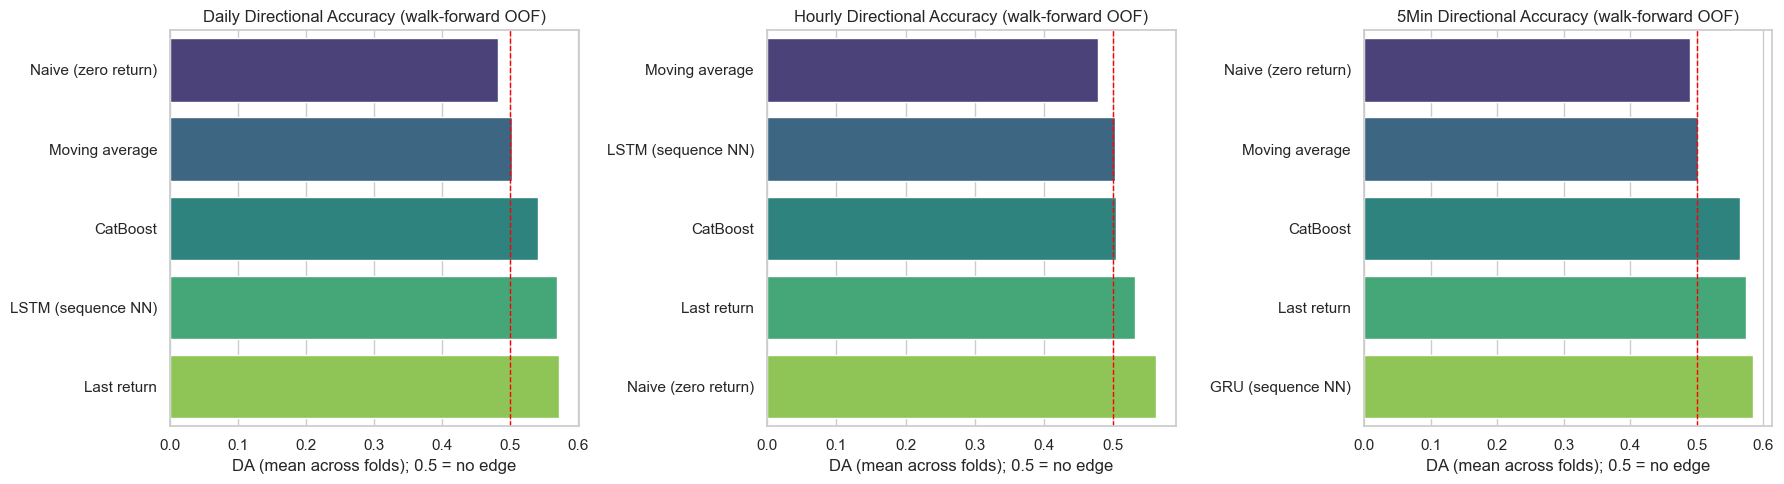

Best model per family by Directional Accuracy:


,frequency,model,family,MAE,RMSE,MASE,DA
0,5min,GRU (sequence NN),NN,0.000538,0.000802,0.6624,0.5843
1,5min,Last return,baseline,0.000699,0.000997,0.8614,0.5733
2,5min,CatBoost,GB,0.000550,0.000820,0.6772,0.5653
3,5min,Moving average,baseline,0.000597,0.000867,0.7348,0.5017
4,5min,Naive (zero return),baseline,0.000551,0.000830,0.6783,0.4893
5,daily,Last return,baseline,0.018379,0.025151,0.7322,0.5724
6,daily,LSTM (sequence NN),NN,0.014250,0.020109,0.5682,0.5683
7,daily,CatBoost,GB,0.015338,0.021291,0.6094,0.5414
8,daily,Moving average,baseline,0.015883,0.021738,0.6319,0.5021
9,daily,Naive (zero return),baseline,0.014322,0.020382,0.5708,0.4828




Reconstructed-price error (continuity with prior report):


,frequency,model,family,SMAPE_price,MAE_price
24,5min,GRU (sequence NN),NN,0.0538,41.62
22,5min,CNN_LSTM (sequence NN),NN,0.0543,42.01
23,5min,CatBoost,GB,0.0550,42.60
30,5min,Naive (zero return),baseline,0.0551,42.66
31,5min,StackedLSTM (sequence NN),NN,0.0552,42.74
26,5min,LSTM (sequence NN),NN,0.0565,43.66
32,5min,XGBoost,GB,0.0567,43.88
25,5min,HistGradientBoosting,GB,0.0576,44.59
29,5min,Moving average,baseline,0.0597,46.21
28,5min,LightGBM,GB,0.0628,48.58




Economic backtest (long/flat, Binance 0.05% maker fee, 2 bps slippage):

--- daily ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
1,CNN_LSTM (sequence NN),Buy&Hold,42737.51,42737.51,0.00,0.766,64044.01,0
0,CNN_LSTM (sequence NN),Strategy,95038.29,95038.29,31790.64,1.847,10105.90,473
3,CatBoost,Buy&Hold,42737.51,42737.51,0.00,0.766,64044.01,0
2,CatBoost,Strategy,75288.63,75288.63,29982.45,1.414,23900.23,361
5,GRU (sequence NN),Buy&Hold,42737.51,42737.51,0.00,0.766,64044.01,0
4,GRU (sequence NN),Strategy,75548.28,75548.28,26160.47,1.524,30415.79,401
7,HistGradientBoosting,Buy&Hold,42737.51,42737.51,0.00,0.766,64044.01,0
6,HistGradientBoosting,Strategy,59852.90,59852.90,26126.33,1.358,19217.36,325
9,LSTM (sequence NN),Buy&Hold,42737.51,42737.51,0.00,0.766,64044.01,0
8,LSTM (sequence NN),Strategy,98389.30,98389.30,32052.50,1.781,14894.80,449



--- hourly ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
23,CNN_LSTM (sequence NN),Buy&Hold,36169.58,36169.58,0.00,3.876,16131.10,0
22,CNN_LSTM (sequence NN),Strategy,-1549.93,-1549.93,47857.42,-0.443,22735.80,461
25,CatBoost,Buy&Hold,36169.58,36169.58,0.00,3.876,16131.10,0
24,CatBoost,Strategy,-81670.08,-81670.08,123407.78,-9.855,85941.51,1065
27,GRU (sequence NN),Buy&Hold,36169.58,36169.58,0.00,3.876,16131.10,0
26,GRU (sequence NN),Strategy,-25552.98,-25552.98,53764.32,-2.885,33442.81,483
29,HistGradientBoosting,Buy&Hold,36169.58,36169.58,0.00,3.876,16131.10,0
28,HistGradientBoosting,Strategy,-77382.38,-77382.38,103365.28,-10.339,78025.27,909
31,LSTM (sequence NN),Buy&Hold,36169.58,36169.58,0.00,3.876,16131.10,0
30,LSTM (sequence NN),Strategy,-57193.83,-57193.83,104732.97,-6.874,62164.71,913



--- 5min ---


,model,type,total_return_usd,pnl_usd,total_fees_usd,sharpe,max_drawdown_usd,turnover
45,CNN_LSTM (sequence NN),Buy&Hold,2711.58,2711.58,0.00,4.678,4358.03,0
44,CNN_LSTM (sequence NN),Strategy,-91533.25,-91533.25,108488.55,-150.308,91533.25,1001
47,CatBoost,Buy&Hold,2711.58,2711.58,0.00,4.678,4358.03,0
46,CatBoost,Strategy,-86832.08,-86832.08,100476.12,-146.125,86832.08,928
49,GRU (sequence NN),Buy&Hold,2711.58,2711.58,0.00,4.678,4358.03,0
48,GRU (sequence NN),Strategy,-113223.48,-113223.48,130028.55,-167.115,113306.95,1199
51,HistGradientBoosting,Buy&Hold,2711.58,2711.58,0.00,4.678,4358.03,0
50,HistGradientBoosting,Strategy,-101345.88,-101345.88,114364.00,-155.410,101345.88,1057
53,LSTM (sequence NN),Buy&Hold,2711.58,2711.58,0.00,4.678,4358.03,0
52,LSTM (sequence NN),Strategy,-101077.64,-101077.64,115344.77,-149.027,101161.12,1061


In [13]:
# Per-fold metrics (return space). SMAPE опущена: на доходностях знаменатель
# обращается в ноль при смене знака; ведущая метрика — Directional Accuracy (DA).
# Непрерывность с прежним отчётом даёт отдельная таблица метрик на восстановленной
# ЦЕНЕ ниже.
print('Walk-forward per-fold metrics (target = log-return):')
for freq in wf_metrics_all:
    print(f'\n--- {freq} ---')
    fold_table = (wf_metrics_all[freq]
                  .sort_values(['model', 'fold'])
                  [['fold', 'model', 'MAE', 'RMSE', 'MASE', 'DA', 'n_train', 'n_test']])
    display(fold_table.round({'MAE': 6, 'RMSE': 6, 'MASE': 4, 'DA': 4}))

print('\n\nWalk-forward aggregate (mean across folds, sorted by Directional Accuracy):')
agg_display = wf_agg.sort_values(['frequency', 'DA'], ascending=[True, False]).copy()
display(agg_display[['frequency', 'model', 'family', 'MAE', 'RMSE', 'MASE', 'DA']]
        .round({'MAE': 6, 'RMSE': 6, 'MASE': 4, 'DA': 4}))

# Headline: Directional Accuracy of naive + best GB + best NN per frequency.
# Пунктирная линия 0.5 — уровень "нет направленного навыка".
baseline_agg = wf_agg[wf_agg['family'] == 'baseline']
headline = (pd.concat([baseline_agg, best_gb, best_nn])
            .sort_values(['frequency', 'DA'], ascending=[True, False]).reset_index(drop=True))

fig, axes = plt.subplots(1, len(wf_frames), figsize=(6 * len(wf_frames), 5), sharey=False)
if len(wf_frames) == 1:
    axes = [axes]
for ax, frequency in zip(axes, wf_frames.keys()):
    subset = headline[headline['frequency'] == frequency].sort_values('DA')
    sns.barplot(data=subset, x='DA', y='model', hue='model', legend=False, ax=ax, palette='viridis')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{frequency.title()} Directional Accuracy (walk-forward OOF)')
    ax.set_xlabel('DA (mean across folds); 0.5 = no edge')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Best model per family by Directional Accuracy:')
display(headline[['frequency', 'model', 'family', 'MAE', 'RMSE', 'MASE', 'DA']]
        .round({'MAE': 6, 'RMSE': 6, 'MASE': 4, 'DA': 4}))

# Price-space continuity metrics (comparable to the prior level-target SMAPE).
print('\n\nReconstructed-price error (continuity with prior report):')
display(price_metrics.sort_values(['frequency', 'SMAPE_price'])
        .round({'SMAPE_price': 4, 'MAE_price': 2}))

# -------------------------------------------------------
# Economic backtest on reconstructed-price OOF (long iff predicted return > 0)
# -------------------------------------------------------
print('\n\nEconomic backtest (long/flat, Binance 0.05% maker fee, 2 bps slippage):')
econ_frames = []
for freq, price_oof in wf_oof_price_all.items():
    strat = simulate_strategy(price_oof, fee_rate=0.0005, slippage_bps=2.0)
    bh = buy_and_hold(price_oof)
    summary = backtest_summary(strat, bh, periods_per_year=PERIODS_PER_YEAR[freq])
    summary['frequency'] = freq
    econ_frames.append(summary)
econ_df = pd.concat(econ_frames, ignore_index=True)

for freq in wf_frames:
    print(f'\n--- {freq} ---')
    subset = econ_df[econ_df['frequency'] == freq].sort_values(['model', 'type'])
    display(subset[['model', 'type', 'total_return_usd', 'pnl_usd', 'total_fees_usd',
                     'sharpe', 'max_drawdown_usd', 'turnover']]
            .round({'total_return_usd': 2, 'pnl_usd': 2, 'total_fees_usd': 2,
                    'sharpe': 3, 'max_drawdown_usd': 2}))


## Interpretation

Feature importance is computed for the best Gradient Boosting model per frequency using permutation importance (model-agnostic, test segment) and SHAP (`TreeExplainer`, when available). For the GRU, feature importance is approximated with gradient-based attribution (mean absolute gradient of the prediction with respect to each scaled exogenous feature), since SHAP's tree explainer does not apply to a PyTorch model. Comparing the two rankings is the basis for research question 3: do GB and the GRU rely on similar predictive signals?


,frequency,model,feature,importance_mean,importance_std
0,5min,CatBoost,ret_lag1,0.0000,0.0000
1,5min,CatBoost,ret_lag2,0.0000,0.0000
2,5min,CatBoost,Litecoin,0.0000,0.0000
3,5min,CatBoost,USD/JPY,0.0000,0.0000
4,5min,CatBoost,ret_mean5,0.0000,0.0000
5,5min,CatBoost,ret_std10,0.0000,0.0000
6,5min,CatBoost,USD/CAD,0.0000,0.0000
7,5min,CatBoost,Cardano,0.0000,0.0000
8,5min,CatBoost,ret_lag10,0.0000,0.0000
9,5min,CatBoost,OBV,0.0000,0.0000


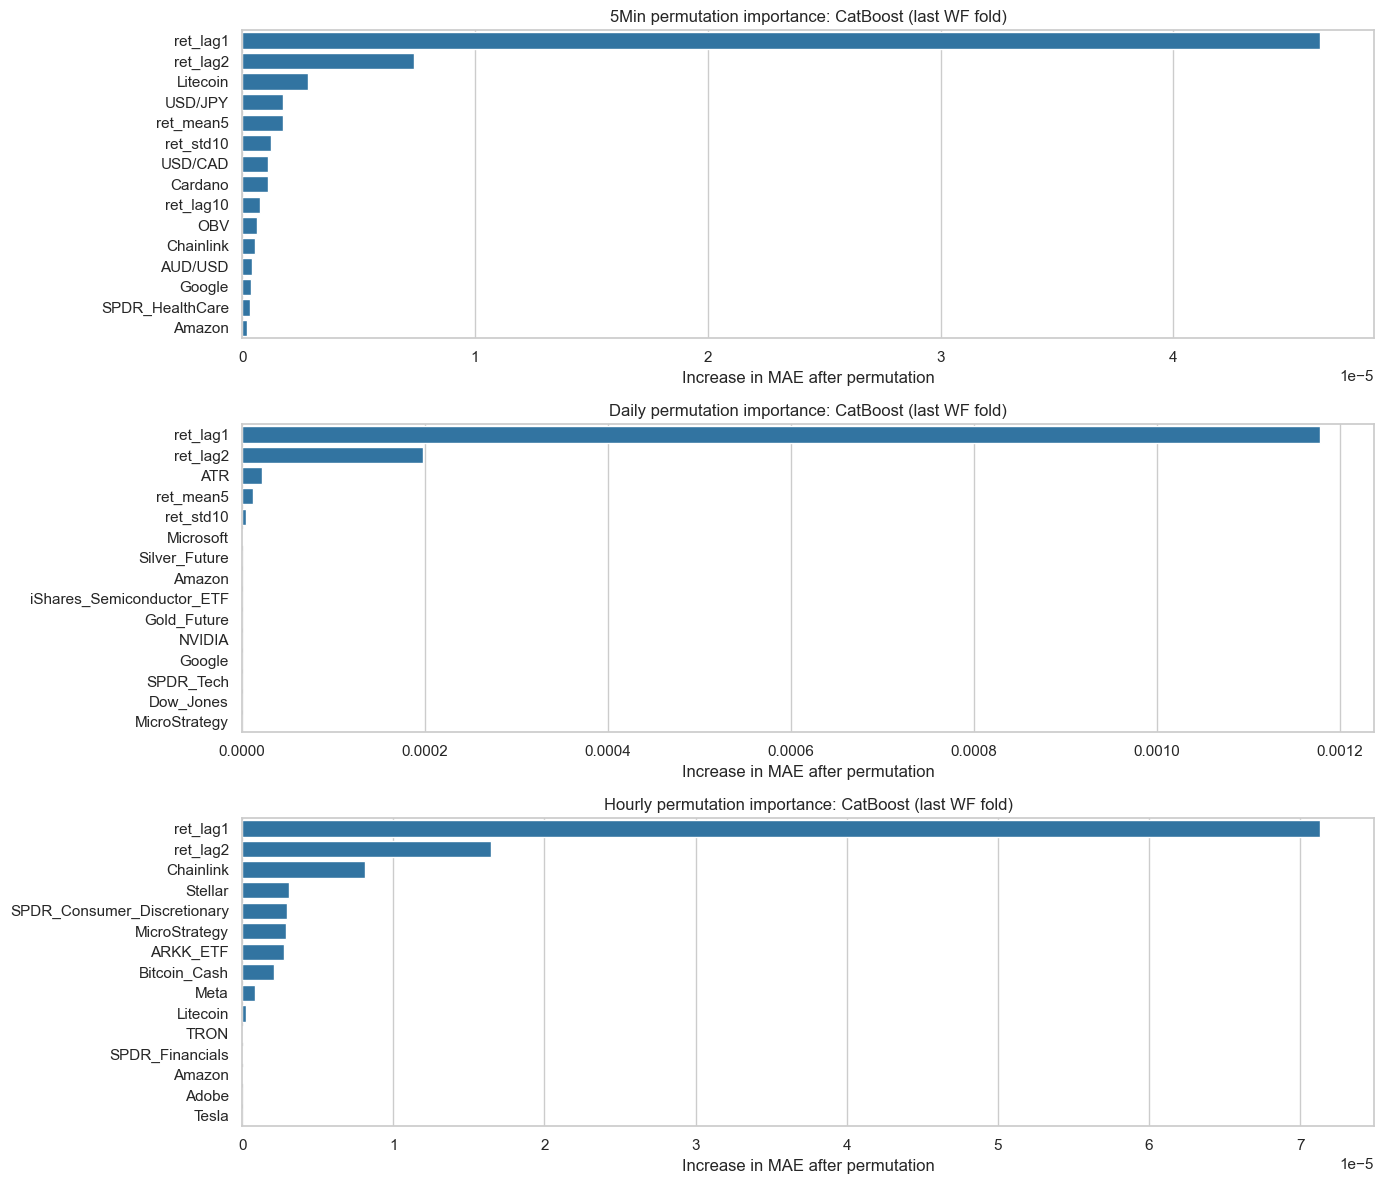

In [14]:
def permutation_importance_table(frequency, model_name, n_repeats=5, top_n=15):
    model = prediction_store[frequency][model_name]['model']
    if model is None or not hasattr(model, 'predict'):
        return pd.DataFrame()
    # Use last walk-forward fold's test data for permutation importance
    n = len(wf_frames[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    X_test_last = wf_frames[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
    y_test_last = wf_frames[frequency]['BTC_logret'].iloc[last_test_idx]
    importance = permutation_importance(
        model,
        X_test_last,
        y_test_last,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
        n_jobs=1,
    )
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': X_test_last.columns,
        'importance_mean': importance.importances_mean,
        'importance_std': importance.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)
    return table

importance_tables = []
for _, row in best_gb.iterrows():
    table = permutation_importance_table(row['frequency'], row['model'])
    if not table.empty:
        importance_tables.append(table)

if importance_tables:
    importance_df = pd.concat(importance_tables, ignore_index=True)
    display(importance_df.round(4))

    fig, axes = plt.subplots(len(importance_tables), 1, figsize=(14, 4 * len(importance_tables)))
    if len(importance_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, importance_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:blue')
        frequency = table['frequency'].iloc[0]
        model_name = table['model'].iloc[0]
        ax.set_title(f'{frequency.title()} permutation importance: {model_name} (last WF fold)')
        ax.set_xlabel('Increase in MAE after permutation')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No permutation importance table was produced for the selected GB models.')


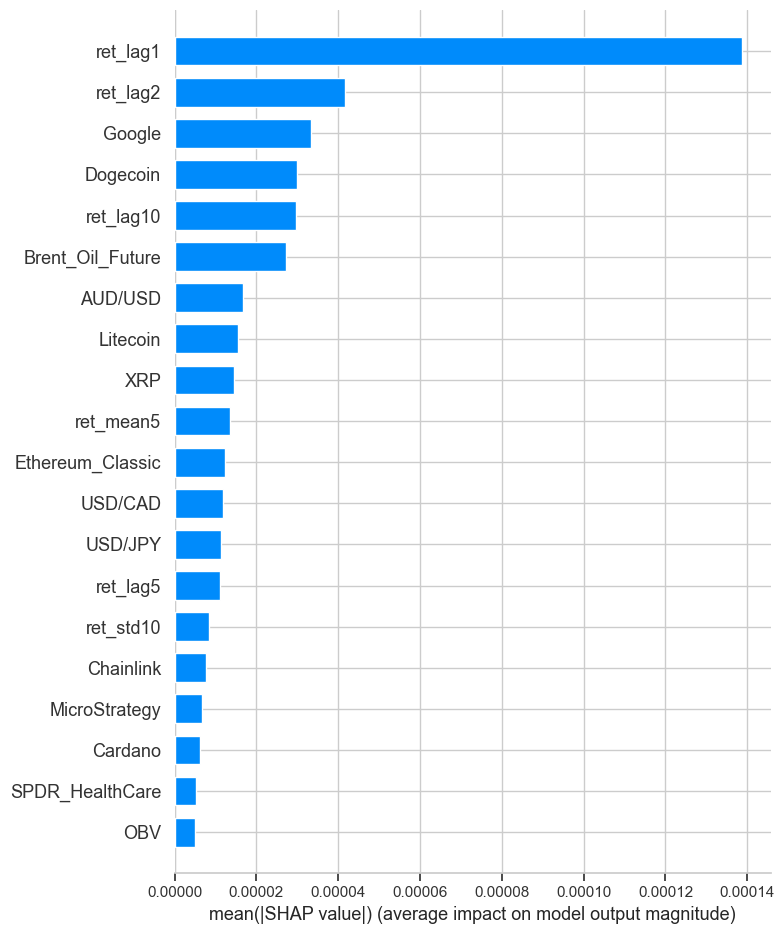

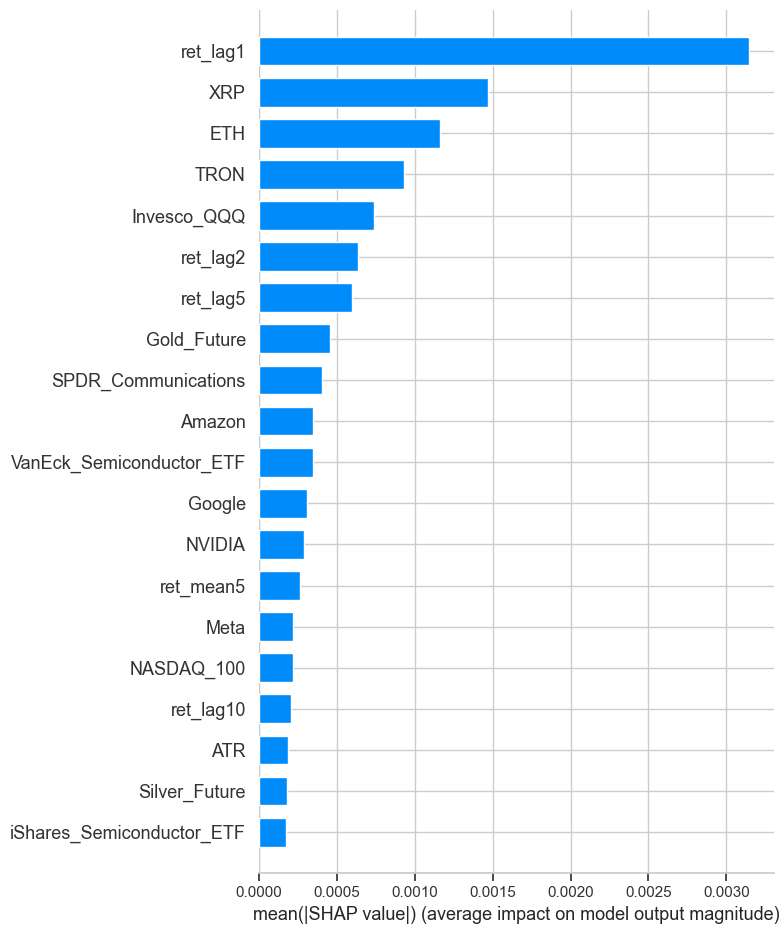

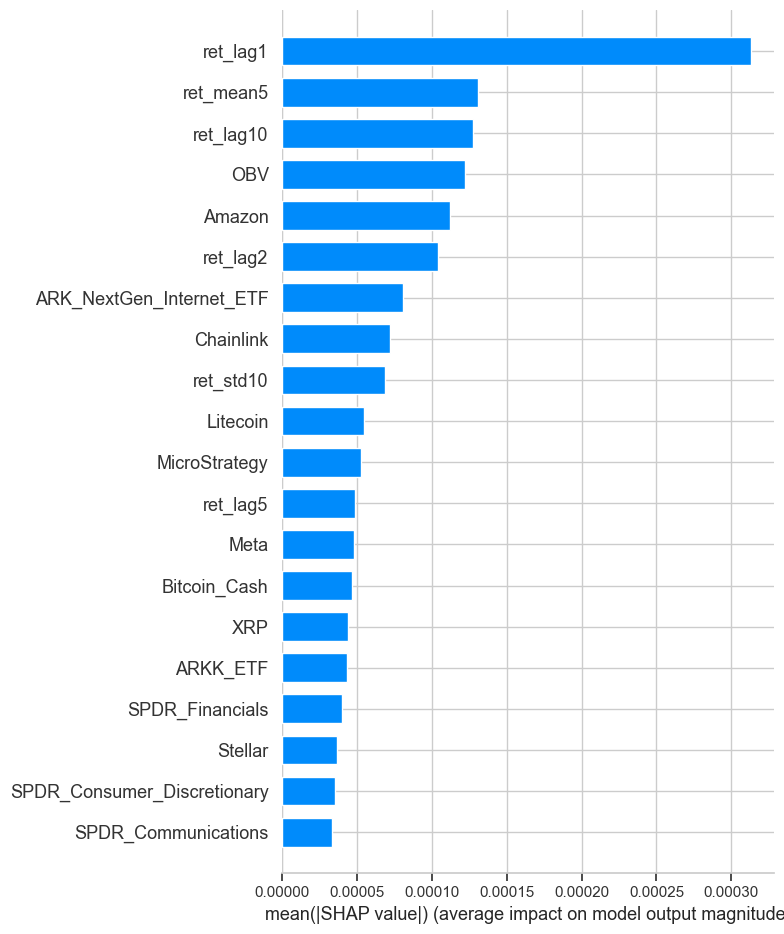

In [15]:
# SHAP interpretation for the best Gradient Boosting model per frequency.
# Uses the refit model (trained on last WF fold's train data) and that fold's test data.
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

if HAS_SHAP:
    for _, row in best_gb.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        model = prediction_store[frequency][model_name]['model']
        if model is None:
            print(f'No refit model for {frequency} {model_name}, skipping SHAP.')
            continue
        # Last WF fold test data (same as permutation importance)
        n = len(wf_frames[frequency])
        _, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
        X_test_last = wf_frames[frequency][TOP_FEATURES[frequency]].iloc[last_test_idx]
        sample = X_test_last.sample(min(500, len(X_test_last)), random_state=RANDOM_STATE)
        estimator = model.named_steps['model'] if isinstance(model, Pipeline) else model
        transformed = model[:-1].transform(sample) if isinstance(model, Pipeline) else sample
        try:
            explainer = shap.TreeExplainer(estimator)
            shap_values = explainer.shap_values(transformed)
            shap.summary_plot(shap_values, sample, plot_type='bar', show=True)
        except Exception as exc:
            print(f'SHAP failed for {frequency} {model_name}: {exc}')
else:
    print('SHAP is not installed in the active environment; permutation importance above is used as the reproducible interpretation method for the GB models.')


,frequency,model,feature,importance_mean,method
0,5min,GRU (sequence NN),USD/JPY,0.1729,Captum IntegratedGradients
1,5min,GRU (sequence NN),Brent_Oil_Future,0.0995,Captum IntegratedGradients
2,5min,GRU (sequence NN),Google,0.0962,Captum IntegratedGradients
3,5min,GRU (sequence NN),AUD/USD,0.0888,Captum IntegratedGradients
4,5min,GRU (sequence NN),USD/CAD,0.0887,Captum IntegratedGradients
5,5min,GRU (sequence NN),Dogecoin,0.0669,Captum IntegratedGradients
6,5min,GRU (sequence NN),ret_lag1,0.0361,Captum IntegratedGradients
7,5min,GRU (sequence NN),ret_lag5,0.0289,Captum IntegratedGradients
8,5min,GRU (sequence NN),ret_lag2,0.0265,Captum IntegratedGradients
9,5min,GRU (sequence NN),Litecoin,0.0259,Captum IntegratedGradients


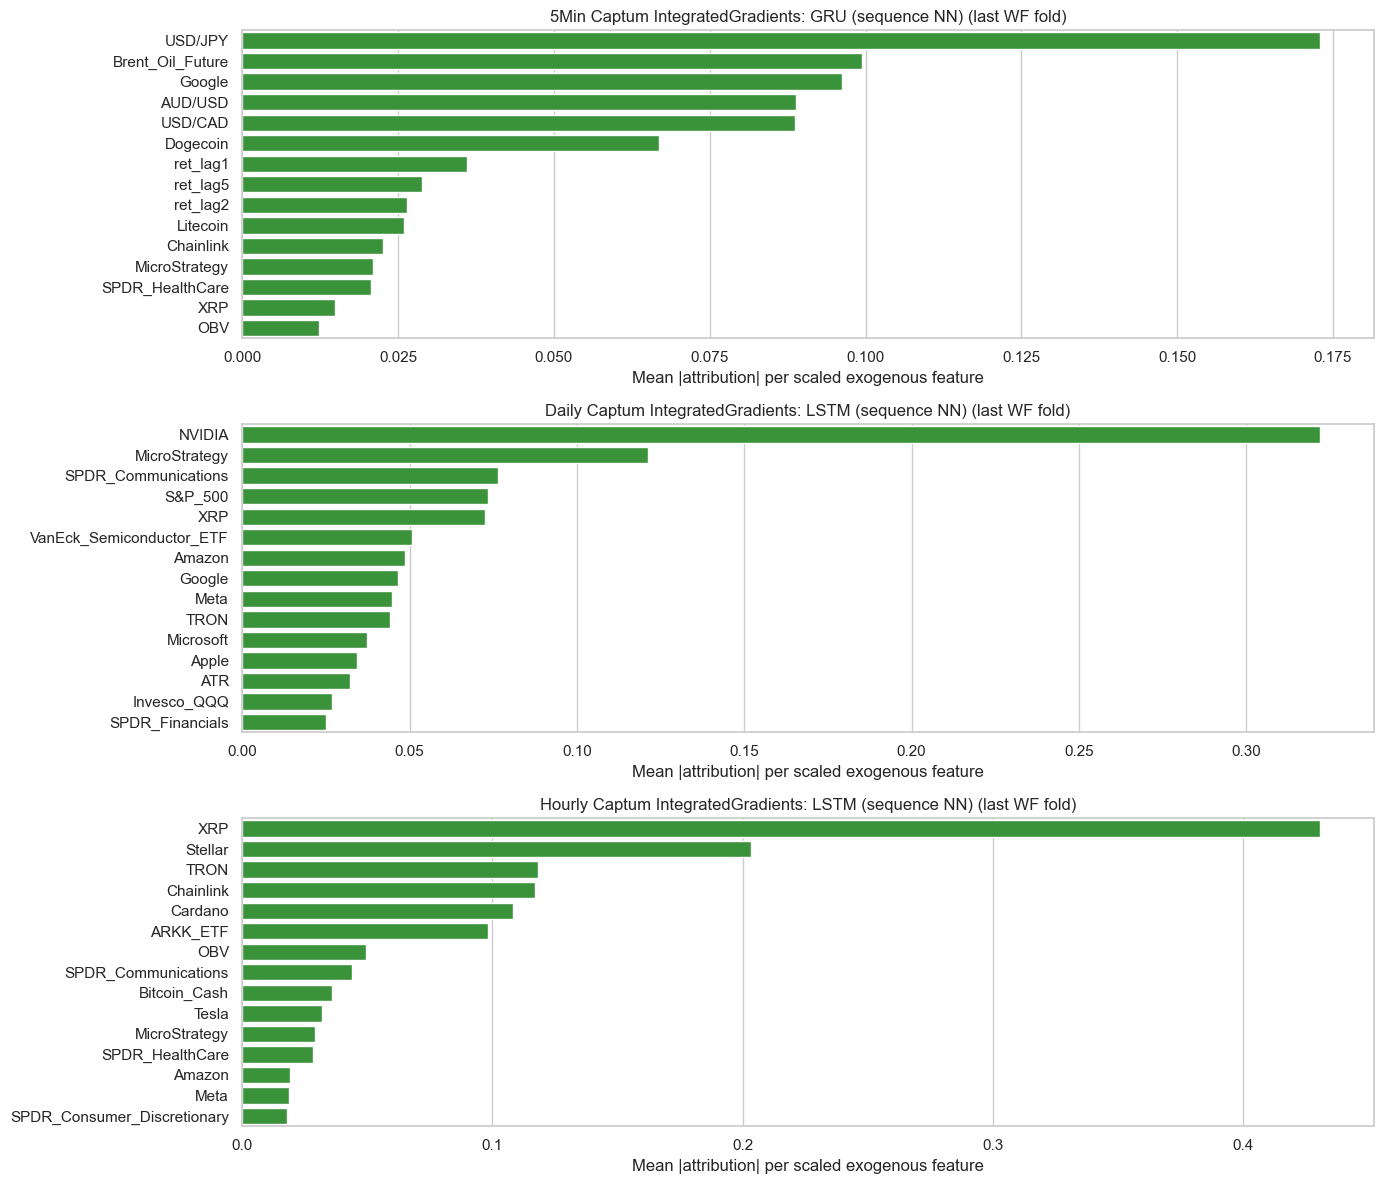

In [16]:
# Captum Integrated Gradients attribution for the best NN per frequency.
# Attributes the exogenous-feature branch of CryptoNet; the BTC-sequence branch
# is held fixed (its values are reused at every interpolation step), isolating
# the marginal contribution of each exogenous feature relative to a zero baseline.
try:
    from captum.attr import IntegratedGradients
    HAS_CAPTUM = True
except ImportError:
    HAS_CAPTUM = False

import torch

nn_attribution_tables = []
for _, row in best_nn.iterrows():
    frequency = row['frequency']
    model_name = row['model']
    reg = prediction_store[frequency][model_name]['model']
    if reg is None or not hasattr(reg, 'model_'):
        print(f'No fitted NN model available for {frequency} {model_name}, skipping.')
        continue

    # Last WF fold test data with window_size history prefix
    n = len(wf_frames[frequency])
    last_train_idx, last_test_idx = _get_splits(frequency, SPLIT_CONFIG[frequency], n)[-1]
    hist_start = max(0, int(last_train_idx[-1]) + 1 - reg.window_size)
    seq_test_df = wf_frames[frequency][TOP_FEATURES[frequency] + ['BTC_logret']].iloc[
        hist_start : int(last_test_idx[-1]) + 1
    ]

    X_seq, X_ex, _, _ = reg._make_windows(seq_test_df)
    X_seq_s = reg.scaler_y_.transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape)
    X_ex_s = reg.scaler_x_.transform(X_ex)

    x_seq_t = torch.tensor(X_seq_s, dtype=torch.float32, device=DEVICE)
    x_ex_t = torch.tensor(X_ex_s, dtype=torch.float32, device=DEVICE)

    reg.model_.eval()

    if HAS_CAPTUM:
        # Ветвь BTC-последовательности фиксируется и идёт через additional_forward_args,
        # чтобы Captum размножил её синхронно с интерполированным x_ex (n_steps).
        def _ig_forward(x_ex, x_seq):
            return reg.model_(x_seq, x_ex).squeeze(-1)   # (N,1)->(N,), чтобы IG не требовал target
        ig = IntegratedGradients(_ig_forward)
        attributions, convergence_delta = ig.attribute(
            x_ex_t,
            baselines=torch.zeros_like(x_ex_t),
            additional_forward_args=(x_seq_t,),
            return_convergence_delta=True,
        )
        importance = attributions.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'Captum IntegratedGradients'
    else:
        # Fallback to plain gradient attribution when captum is unavailable
        x_ex_grad = x_ex_t.clone().requires_grad_(True)
        reg.model_(x_seq_t, x_ex_grad).sum().backward()
        importance = x_ex_grad.grad.detach().abs().cpu().numpy().mean(axis=0)
        method_label = 'gradient attribution (backward)'

    feature_names = reg.feature_cols if hasattr(reg, 'feature_cols') and reg.feature_cols else TOP_FEATURES[frequency]
    table = pd.DataFrame({
        'frequency': frequency,
        'model': model_name,
        'feature': feature_names,
        'importance_mean': importance,
        'method': method_label,
    }).sort_values('importance_mean', ascending=False).head(15)
    nn_attribution_tables.append(table)

if nn_attribution_tables:
    nn_attribution_df = pd.concat(nn_attribution_tables, ignore_index=True)
    display(nn_attribution_df.round(4))

    fig, axes = plt.subplots(len(nn_attribution_tables), 1, figsize=(14, 4 * len(nn_attribution_tables)))
    if len(nn_attribution_tables) == 1:
        axes = [axes]
    for ax, table in zip(axes, nn_attribution_tables):
        sns.barplot(data=table, x='importance_mean', y='feature', ax=ax, color='tab:green')
        freq_lbl = table['frequency'].iloc[0]
        mname_lbl = table['model'].iloc[0]
        method_lbl = table['method'].iloc[0]
        ax.set_title(f'{freq_lbl.title()} {method_lbl}: {mname_lbl} (last WF fold)')
        ax.set_xlabel('Mean |attribution| per scaled exogenous feature')
        ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No NN models were available for attribution.')


## Error Analysis

Residual analysis covers the best Gradient Boosting model (`best_gb`) and the GRU (`best_nn`) per frequency: residual shape, temporal behavior of forecasts, and how errors compare during normal periods versus sharp BTC growth or decline (compared against the `Naive last value` baseline).


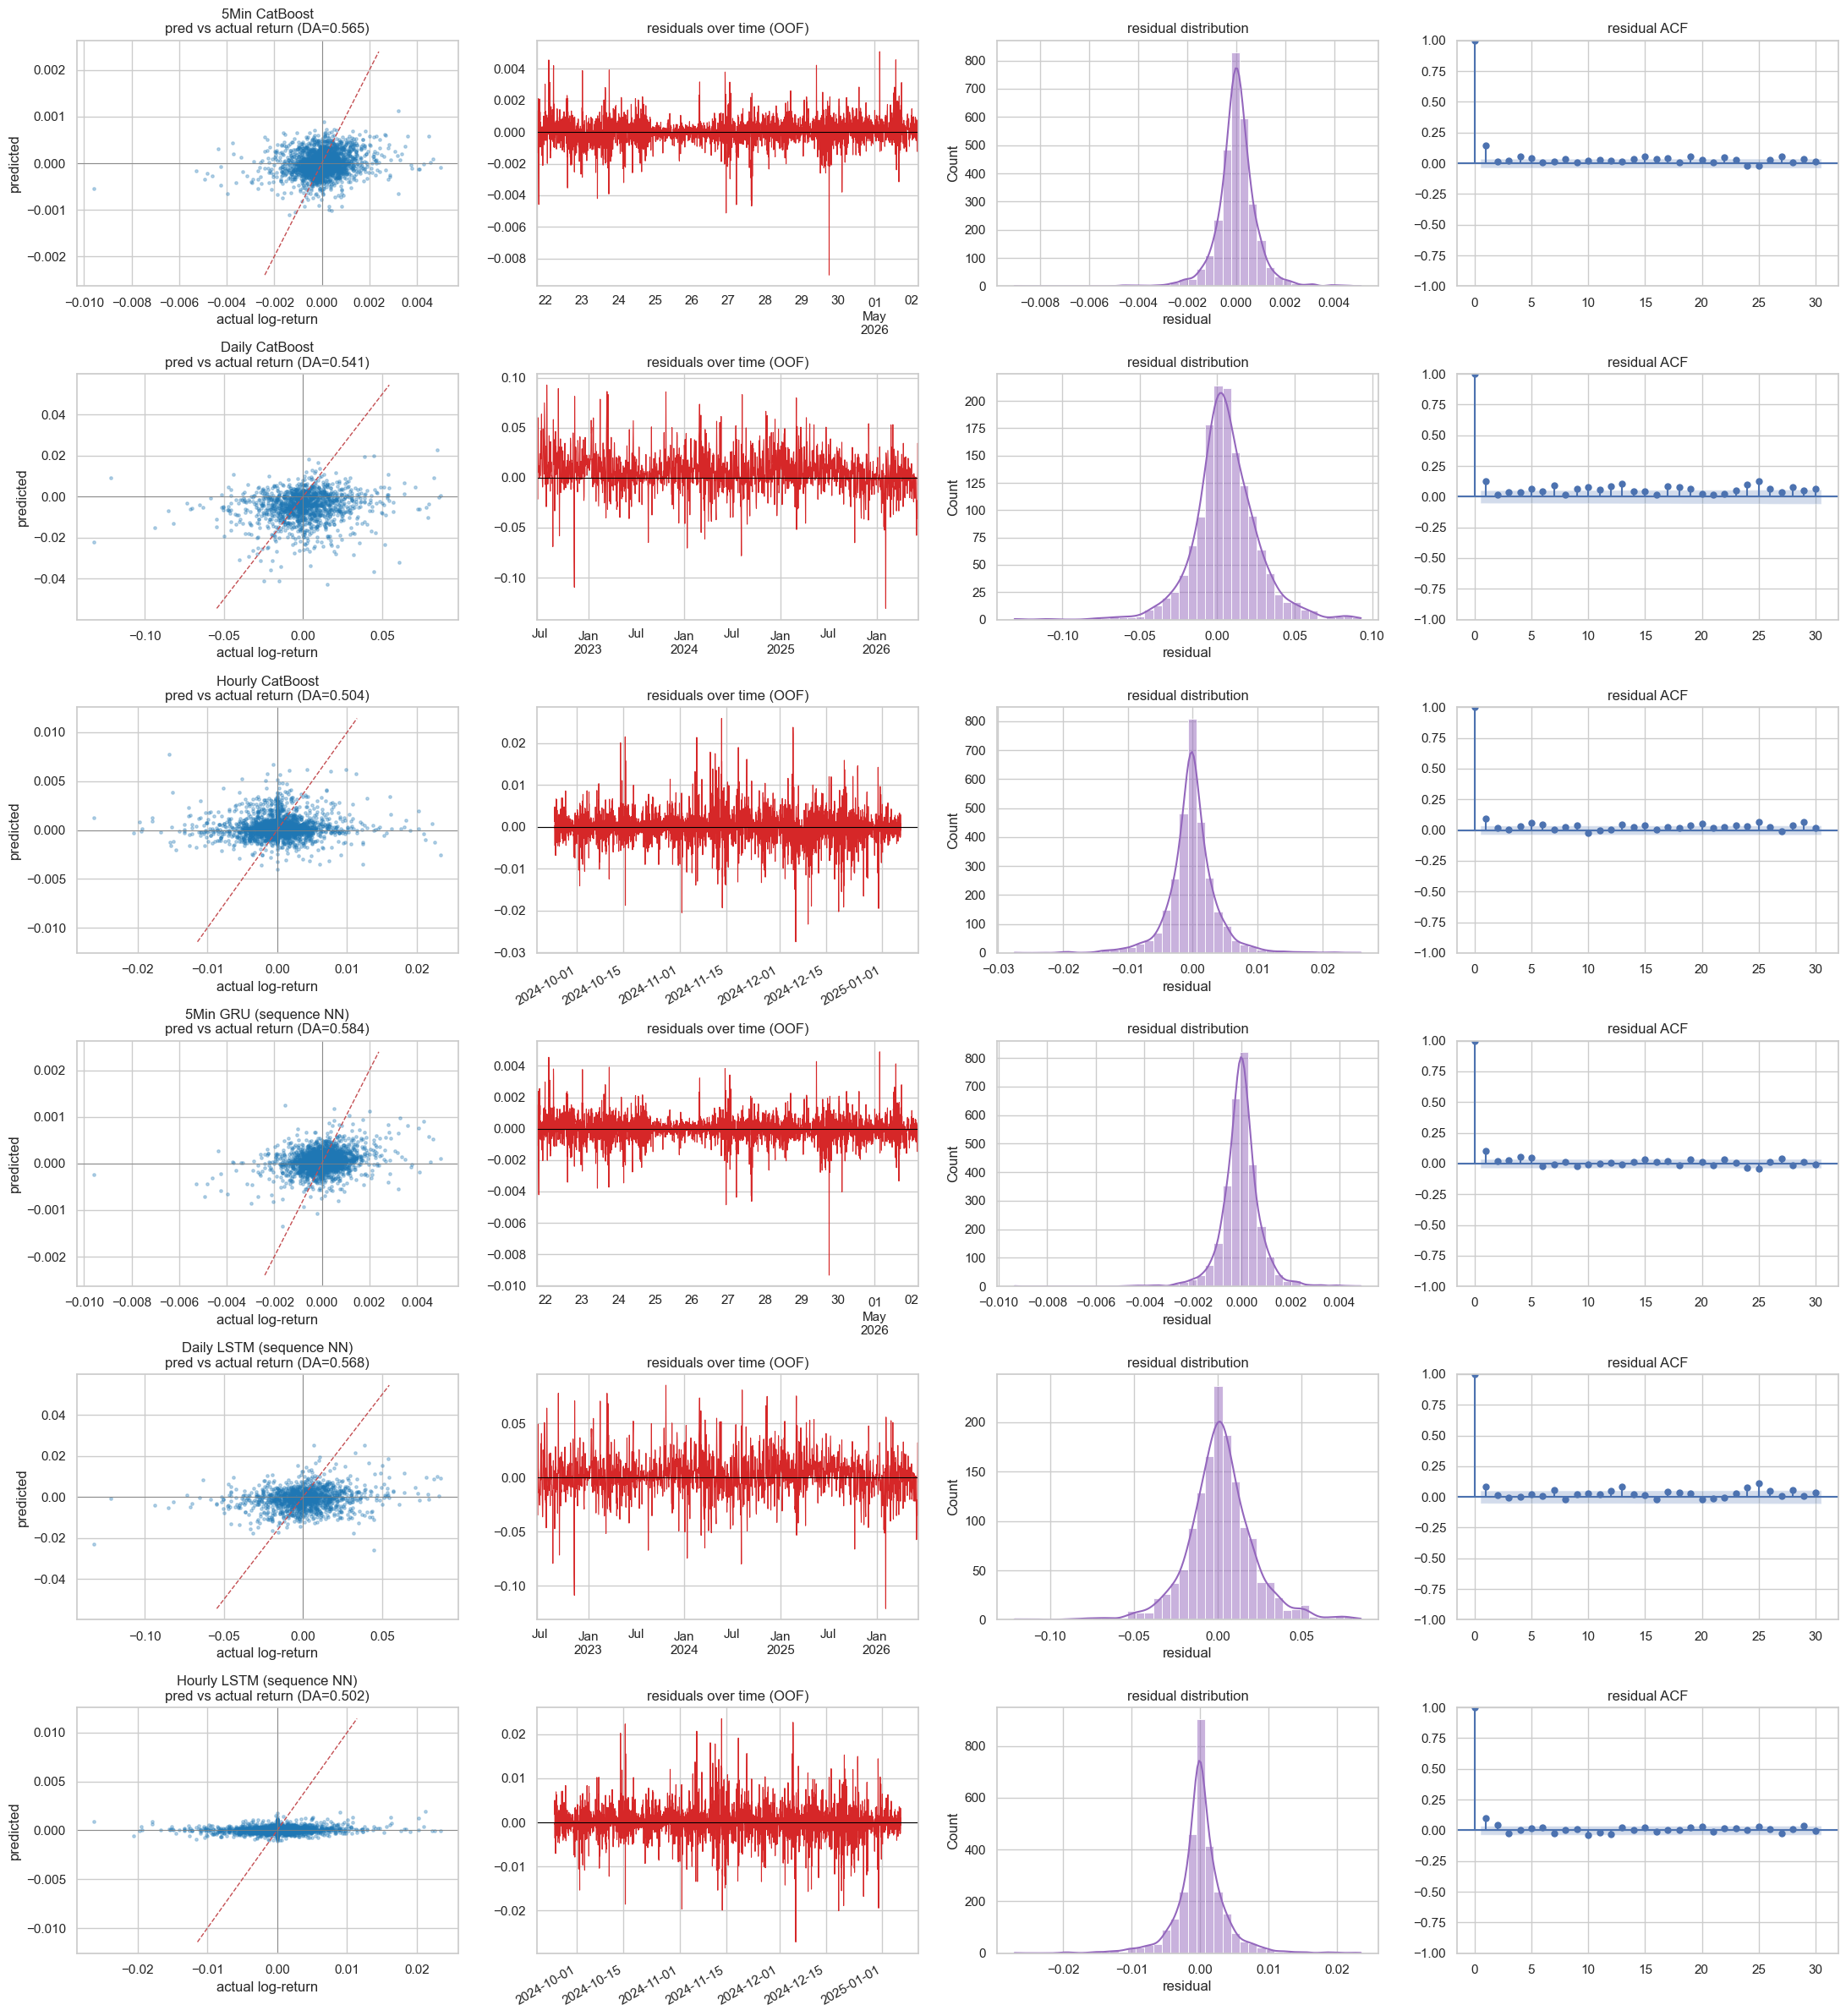

In [17]:
from statsmodels.graphics.tsaplots import plot_acf


def residual_frame(frequency, model_name):
    """Остатки из OOF-прогнозов walk-forward в пространстве ДОХОДНОСТИ.

    actual/forecast - реализованная и прогнозная лог-доходность; residual =
    actual - forecast; pct_return - сама реализованная доходность (для сегментации
    шоков в анализе ниже).
    """
    oof_pred = prediction_store[frequency][model_name]['test_pred'].sort_index().dropna()
    actual = wf_frames[frequency]['BTC_logret'].reindex(oof_pred.index)
    frame = pd.DataFrame({'actual': actual, 'forecast': oof_pred}).dropna()
    frame['residual'] = frame['actual'] - frame['forecast']
    frame['abs_error'] = frame['residual'].abs()
    frame['pct_return'] = frame['actual']
    return frame


error_analysis_rows = pd.concat([best_gb, best_nn]).reset_index(drop=True)

fig, axes = plt.subplots(len(error_analysis_rows), 4, figsize=(22, 4 * len(error_analysis_rows)))
if len(error_analysis_rows) == 1:
    axes = axes.reshape(1, -1)

for row_idx, (_, row) in enumerate(error_analysis_rows.iterrows()):
    frequency = row['frequency']
    model_name = row['model']
    frame = residual_frame(frequency, model_name)

    # (1) Прогноз vs факт ДОХОДНОСТИ: scatter с линией 45°. На уровне цены такой
    # график обманчиво идеален (прогноз ~ вчерашняя цена); на доходностях он честно
    # показывает наличие/отсутствие направленного навыка (облако вокруг 45° = навык,
    # вертикальное облако у нуля = модель почти всегда предсказывает ~0).
    ax = axes[row_idx, 0]
    ax.scatter(frame['actual'], frame['forecast'], s=6, alpha=0.3, color='tab:blue')
    lim = np.nanpercentile(np.abs(frame[['actual', 'forecast']].values), 99)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
    ax.axhline(0, color='grey', lw=0.6)
    ax.axvline(0, color='grey', lw=0.6)
    da = float(np.mean((frame['actual'] > 0) == (frame['forecast'] > 0)))
    ax.set_title(f'{frequency.title()} {model_name}\npred vs actual return (DA={da:.3f})')
    ax.set_xlabel('actual log-return')
    ax.set_ylabel('predicted')

    # (2) Ряд остатков во времени
    frame['residual'].plot(ax=axes[row_idx, 1], color='tab:red', linewidth=0.8)
    axes[row_idx, 1].axhline(0, color='black', linewidth=0.8)
    axes[row_idx, 1].set_title('residuals over time (OOF)')
    axes[row_idx, 1].set_xlabel('')

    # (3) Распределение остатков
    sns.histplot(frame['residual'], bins=40, kde=True, ax=axes[row_idx, 2], color='tab:purple')
    axes[row_idx, 2].set_title('residual distribution')

    # (4) ACF остатков: значимая автокорреляция => модель оставила невыбранную
    # предсказуемую структуру (неполная спецификация). Белый шум => спецификация ок.
    max_lags = max(1, min(30, len(frame) // 2 - 1))
    plot_acf(frame['residual'].dropna(), ax=axes[row_idx, 3], lags=max_lags)
    axes[row_idx, 3].set_title('residual ACF')

plt.tight_layout()
plt.show()


In [18]:
# Shock-period error analysis in RETURN space.
# Сегменты OOF по величине реализованной доходности: |r| > k*std(r), k=2 (основной)
# и k=3 (проверка чувствительности). Для лучших GB/NN и бэйзлайнов считаем
# MAE/MASE/Directional Accuracy по сегментам "резкий рост"/"резкое падение"/"норма".
SHOCK_K_VALUES = [2, 3]

baseline_wf = wf_agg[wf_agg['family'] == 'baseline']
shock_candidates = pd.concat([baseline_wf, best_gb, best_nn]).reset_index(drop=True)

shock_rows = []
shock_detail_rows = []

for k in SHOCK_K_VALUES:
    for _, row in shock_candidates.iterrows():
        frequency = row['frequency']
        model_name = row['model']
        frame = residual_frame(frequency, model_name).dropna(subset=['pct_return'])
        if frame.empty:
            continue

        ret_std = frame['pct_return'].std()
        threshold = k * ret_std
        frame = frame.copy()
        frame['shock_type'] = np.where(
            frame['pct_return'] >= threshold, 'sharp growth',
            np.where(frame['pct_return'] <= -threshold, 'sharp drop', 'normal'),
        )

        oof_start_pos = wf_frames[frequency].index.get_loc(frame.index[0])
        y_train_proxy = wf_frames[frequency]['BTC_logret'].iloc[:oof_start_pos].to_numpy(dtype=float)

        for shock_type, group in frame.groupby('shock_type'):
            metrics = regression_metrics(
                group['actual'].values, group['forecast'].values,
                y_train_proxy if len(y_train_proxy) > 1 else group['actual'].values,
            )
            shock_rows.append({
                'k': k, 'frequency': frequency, 'model': model_name,
                'period_type': shock_type,
                'threshold_ret': round(threshold, 5),
                'n_observations': len(group),
                'MAE': metrics['MAE'], 'MASE': metrics['MASE'], 'DA': metrics['DA'],
            })

        if k == 2:
            shocks = frame[frame['shock_type'] != 'normal'].copy()
            shocks['abs_ret'] = shocks['pct_return'].abs()
            for time, values in shocks.sort_values('abs_ret', ascending=False).head(10).iterrows():
                shock_detail_rows.append({
                    'frequency': frequency, 'model': model_name, 'time': time,
                    'shock_type': values['shock_type'], 'realized_return': values['pct_return'],
                    'actual_ret': values['actual'], 'forecast_ret': values['forecast'],
                    'abs_error': values['abs_error'],
                })

shock_summary = pd.DataFrame(shock_rows)
shock_details = pd.DataFrame(shock_detail_rows)

print('Shock-period error analysis (|return| > 2*std), return space:')
display(shock_summary[shock_summary['k'] == 2].drop(columns='k')
        .round({'MAE': 6, 'MASE': 4, 'DA': 4, 'threshold_ret': 5}))

print('\nSensitivity check (|return| > 3*std):')
display(shock_summary[shock_summary['k'] == 3].drop(columns='k')
        .round({'MAE': 6, 'MASE': 4, 'DA': 4, 'threshold_ret': 5}))

print('\nTop individual shocks per frequency/model (k=2):')
display(shock_details.round({'realized_return': 5, 'actual_ret': 5, 'forecast_ret': 5, 'abs_error': 5}))


Shock-period error analysis (|return| > 2*std), return space:


,frequency,model,period_type,threshold_ret,n_observations,MAE,MASE,DA
0,daily,Last return,normal,0.04098,1368,0.016548,0.6054,0.5658
1,daily,Last return,sharp drop,0.04098,36,0.048465,1.7730,0.6944
2,daily,Last return,sharp growth,0.04098,46,0.049284,1.8030,0.6739
3,daily,Moving average,normal,0.04098,1368,0.013504,0.4940,0.4993
4,daily,Moving average,sharp drop,0.04098,36,0.056669,2.0732,0.5278
5,daily,Moving average,sharp growth,0.04098,46,0.054720,2.0019,0.5652
6,daily,Naive (zero return),normal,0.04098,1368,0.011753,0.4300,0.4854
7,daily,Naive (zero return),sharp drop,0.04098,36,0.058323,2.1337,1.0000
8,daily,Naive (zero return),sharp growth,0.04098,46,0.056283,2.0590,0.0000
9,hourly,Last return,normal,0.00764,2814,0.003081,0.8420,0.5249



Sensitivity check (|return| > 3*std):


,frequency,model,period_type,threshold_ret,n_observations,MAE,MASE,DA
45,daily,Last return,normal,0.06147,1428,0.017741,0.6490,0.5686
46,daily,Last return,sharp drop,0.06147,10,0.068232,2.4962,0.7000
47,daily,Last return,sharp growth,0.06147,12,0.052726,1.9289,0.9167
48,daily,Moving average,normal,0.06147,1428,0.014950,0.5469,0.5014
49,daily,Moving average,sharp drop,0.06147,10,0.080931,2.9608,0.6000
50,daily,Moving average,sharp growth,0.06147,12,0.072707,2.6599,0.5000
51,daily,Naive (zero return),normal,0.06147,1428,0.013296,0.4864,0.4832
52,daily,Naive (zero return),sharp drop,0.06147,10,0.085820,3.1396,1.0000
53,daily,Naive (zero return),sharp growth,0.06147,12,0.076847,2.8114,0.0000
54,hourly,Last return,normal,0.01146,2940,0.003281,0.8968,0.5306



Top individual shocks per frequency/model (k=2):


,frequency,model,time,shock_type,realized_return,actual_ret,forecast_ret,abs_error
0,daily,Last return,2022-11-09 00:00:00,sharp drop,-0.13197,-0.13197,-0.09366,0.03832
1,daily,Last return,2026-02-05 00:00:00,sharp drop,-0.12169,-0.12169,-0.02876,0.09293
2,daily,Last return,2022-11-08 00:00:00,sharp drop,-0.09366,-0.09366,-0.01642,0.07724
3,daily,Last return,2023-03-13 00:00:00,sharp growth,0.08698,0.08698,0.05721,0.02976
4,daily,Last return,2023-10-23 00:00:00,sharp growth,0.08573,0.08573,0.00252,0.08321
...,...,...,...,...,...,...,...,...
145,hourly,LSTM (sequence NN),2024-11-06 02:00:00,sharp growth,0.02100,0.02100,0.00036,0.02064
146,hourly,LSTM (sequence NN),2024-12-18 20:00:00,sharp drop,-0.02059,-0.02059,-0.00056,0.02003
147,hourly,LSTM (sequence NN),2024-11-06 03:00:00,sharp growth,0.02024,0.02024,0.00129,0.01895
148,hourly,LSTM (sequence NN),2024-10-14 03:00:00,sharp growth,0.02022,0.02022,0.00005,0.02018


## Discussion

**Постановка задачи.** Все модели прогнозируют одношаговую лог-доходность
`r_t = log(P_t) - log(P_{t-1})`, а не уровень цены. Этот выбор устраняет три артефакта
уровневой постановки: (1) неспособность деревьев экстраполировать растущий тренд
(бустинги ограничены диапазоном таргета на трейне и систематически недооценивали в
поздних фолдах, из-за чего сравнение GB vs NN было некорректным); (2) вырождение SMAPE
на уровне до персистентности; (3) завышение MASE из-за смены ценового режима между
трейном и тестом. На стационарном таргете доходности GB и NN сравниваются на равных, а
уровень цены восстанавливается как `P_t = P_{t-1}·exp(r_t)`.

**Защита от утечки.** Зазор «признаки предшествуют таргету» обеспечивается на двух
уровнях: экзогенные ряды лагируются ещё в `get_data` (несинхронные сессии, лаг
публикации макро), а контемпоранные BTC-производные (RSI/MACD/ATR/OBV, скользящие
статистики) и признаки доходности строятся строго лагированными в `prep_returns`. Отбор
признаков (top-k по |Pearson|), импьютинг, клиппинг и скейлинг переобучаются внутри
каждого тренировочного фолда; гиперпараметры подбираются Optuna во вложенном
`TimeSeriesSplit`/валидационном хвосте. Интерпретация (permutation / SHAP / Captum)
считается на тех же сдвинутых фреймах и тех же моделях, метрики которых докладываются, —
рассогласования «оцениваем одно, интерпретируем другое» больше нет.

**Метрики.** Ведущая метрика — Directional Accuracy: на почти-случайном блуждании цены
MAE/RMSE доходности у всех моделей близки, и только доля верного знака отвечает на
вопрос о наличии торгуемого навыка. MASE сравнивает с наивным (нулевым) прогнозом
доходности; SMAPE приводится лишь на восстановленной цене ради сопоставимости с прежним
отчётом. Финальный арбитр практической ценности — экономический бэктест против Buy&Hold
с учётом комиссий (0.05% мейкер) и проскальзывания (2 б.п.); Sharpe считается на
процентных доходностях, а не на USD-PnL.

**Сравнение архитектур.** Вывод опирается на таблицы Directional Accuracy и бэктеста
выше. Если ни одна модель устойчиво не превышает DA ≈ 0.5 и не превосходит Buy&Hold
после издержек, корректный научный вывод — отсутствие устойчивого направленного навыка
на данных горизонтах (что согласуется со слабой формой эффективности крипторынка), а не
превосходство какой-либо одной архитектуры. Любое преимущество следует трактовать в
терминах DA/Sharpe относительно бэйзлайнов, а не низкого SMAPE на уровне цены.


## Conclusion

* Пайплайн прогнозирует одношаговую **лог-доходность** BTC на трёх частотах (дневная,
  часовая, 5-минутная) и честно сравнивает 4 бустинга (HistGB, LightGBM, XGBoost,
  CatBoost) и 4 нейросетевые архитектуры (LSTM, GRU, StackedLSTM, CNN-LSTM) в
  walk-forward (expanding для дневных, rolling для внутридневных, по 5 фолдов) с
  переподбором гиперпараметров Optuna на каждом фолде.
* Переход от уровня цены к доходности снял артефакт неспособности деревьев
  экстраполировать тренд и сделал метрики содержательными; ведущей метрикой выбрана
  **Directional Accuracy**, практическим критерием — экономический бэктест против
  **Buy&Hold** с комиссиями и проскальзыванием.
* Все шаги препроцессинга и отбора признаков выполняются строго внутри тренировочных
  фолдов, а интерпретация согласована с оцениваемыми моделями — методологических утечек
  «из будущего» в оцениваемом контуре нет.
* Лучшая модель каждого семейства и итоговый вывод о наличии/отсутствии торгуемого
  навыка определяются таблицами Directional Accuracy и экономического бэктеста выше.
* Дальнейшая работа: отбор признаков полностью внутри фолда (без глобального
  преселекта пула), вероятностный/квантильный прогноз распределения доходности,
  мультистеп-горизонты и режимно-зависимые торговые правила.
